**Table of contents**
1. [Set up and config](#1)
2. [Xử lý dữ liệu và EDA](#2)
3. [Mô hình và huấn luyện mô hình](#3)
4. [Đánh giá mô hình](#4)

# 1. Set up and config <a id='1'></a>

In [1]:
# Core Python + third-party
import time
from dataclasses import asdict, is_dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [2]:
# Project modules
from config import (
    GaussianNaiveBayesConfig,
    KernelLogisticRegressionConfig,
    LDAConfig,
    LogisticRegressionConfig,
    PerceptronConfig,
    ProbitRegressionConfig,
    QDAConfig,
    SoftmaxRegressionConfig,
)

from preprocessing import prepare_classification_data, make_binary_subset
from tuning import tune_logistic_regularization
from eda import (
    summarize_dataset,
    summarize_numeric_statistics,
    plot_class_distribution,
    plot_correlation_heatmap,
    plot_top_feature_distributions,
)
from experiments import (
    fisher_ratio_ranking,
    ovr_predict_with_logistic,
    ovo_predict_with_logistic,
    run_perceptron_toy_convergence,
)
from eval import (
    classification_report,
    collect_models_with_attr,
    compare_average_precision,
    evaluate_multiclass_strategy,
    kfold_cross_val_score,
    mcnemar_paired,
    plot_loss_curves,
    plot_roc_curve,
    reliability_diagram_multiclass,
    sparsity_ratio,
)
from models import (
    GaussianNaiveBayes,
    KernelLogisticRegression,
    LDA,
    LogisticRegression,
    Perceptron,
    ProbitRegression,
    QDA,
    SoftmaxRegression,
)
import utils as utils_module

In [3]:
import time
from dataclasses import asdict, is_dataclass

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [4]:
from config import (
  # ClassificationNotebookConfig,
  GaussianNaiveBayesConfig,
  KernelLogisticRegressionConfig,
  LDAConfig,
  LogisticRegressionConfig,
  PerceptronConfig,
  ProbitRegressionConfig,
  QDAConfig,
  SoftmaxRegressionConfig,
)
from preprocessing import prepare_classification_data, make_binary_subset
from tuning import tune_logistic_regularization
from eda import (
  summarize_dataset,
  summarize_numeric_statistics,
  plot_class_distribution,
  plot_correlation_heatmap,
  plot_top_feature_distributions,
)
from experiments import (
  fisher_ratio_ranking,
  ovr_predict_with_logistic,
  ovo_predict_with_logistic,
  run_perceptron_toy_convergence,
)
from eval import (
  classification_report,
  collect_models_with_attr,
  compare_average_precision,
  evaluate_multiclass_strategy,
  kfold_cross_val_score,
  mcnemar_paired,
  plot_loss_curves,
  plot_roc_curve,
  reliability_diagram_multiclass,
  sparsity_ratio,
)
import utils as utils_module
from models import (
  GaussianNaiveBayes,
  KernelLogisticRegression,
  LDA,
  LogisticRegression,
  Perceptron,
  ProbitRegression,
  QDA,
  SoftmaxRegression,
)

# notebook_cfg = ClassificationNotebookConfig()

# Base configs from config.py
logreg_cfg = LogisticRegressionConfig()
softmax_cfg = SoftmaxRegressionConfig()
perceptron_cfg = PerceptronConfig(max_iter=5000)
probit_cfg = ProbitRegressionConfig()
kernel_log_cfg = KernelLogisticRegressionConfig()
lda_cfg = LDAConfig()
qda_cfg = QDAConfig()
gnb_cfg = GaussianNaiveBayesConfig()

# Notebook-specific overrides for LR regularization experiments
logreg_l1_cfg = LogisticRegressionConfig(l1_penalty=1e-3)
logreg_l2_cfg = LogisticRegressionConfig(l2_penalty=1e-3)
logreg_elastic_cfg = LogisticRegressionConfig(l1_penalty=5e-4, l2_penalty=5e-4)

def build_from_config(model_cls, cfg):
  if is_dataclass(cfg):
    return model_cls(**asdict(cfg))
  return model_cls(**dict(vars(cfg)))

## Configuaration

In [5]:
SEED = 42
ALPHA = 0.05
DATA_PATH = '../../data/raw/dry-bean-dataset/Dry_Bean_Dataset.xlsx'
TARGET_COL = 'Class'
TEST_SIZE = 0.2
VAL_SIZE = 0.1
BINARY_CLASSES = (0, 2) # 
BINARY_FEATURE_INDICES = (0, 1)
KFOLD_SPLITS = 5
N_BINS = 10

In [6]:
def set_seed(seed: int) -> None:
  np.random.seed(seed)

set_seed(SEED)

# 2. Xử lý dữ liệu và EDA <a id='2'></a>
- Không validation:
$\text{Train} : \text{Test} = 80\% : 20\%$
- Có validation:
$\text{Train} : \text{Val} : \text{Test} = 70\% : 10\% : 20\%$

## 2.1 Xử lý dữ liệu

In [7]:
prepared = prepare_classification_data(
  file_path=DATA_PATH,
  target_col=TARGET_COL,
  test_size=TEST_SIZE,
  val_size=VAL_SIZE,
  random_state=SEED,
)

df = prepared.df
X = prepared.X
y = prepared.y

X_train = prepared.X_train
X_val = prepared.X_val
X_test = prepared.X_test

X_train_scaled = prepared.X_train_scaled
X_val_scaled = prepared.X_val_scaled
X_test_scaled = prepared.X_test_scaled

y_train = prepared.y_train
y_val = prepared.y_val
y_test = prepared.y_test

target_le = prepared.target_encoder

# Keep train+val aliases for later experiments when needed.
X_train_val = np.vstack([X_train_scaled, X_val_scaled])
y_train_val = np.concatenate([y_train, y_val])

Loaded ../../data/raw/dry-bean-dataset/Dry_Bean_Dataset.xlsx -> shape (13611, 17)
Split sizes -> train: 9527, val: 1361, test: 2723


In [8]:
print(f"X_train_scaled.shape: {X_train_scaled.shape}")
print(f"y_train.shape: {y_train.shape}")
print(f"X_test_scaled.shape: {X_test_scaled.shape}")
print(f"y_test.shape: {y_test.shape}")

X_train_scaled.shape: (9527, 16)
y_train.shape: (9527,)
X_test_scaled.shape: (2723, 16)
y_test.shape: (2723,)


In [9]:
print(f"X_train_val.shape: {X_train_val.shape}")
print(f"y_train_val.shape: {y_train_val.shape}")
print(f"X_val.shape: {X_val.shape}")
print(f"y_val.shape: {y_val.shape}")

X_train_val.shape: (10888, 16)
y_train_val.shape: (10888,)
X_val.shape: (1361, 16)
y_val.shape: (1361,)


In [10]:
C = np.unique(y_train).shape[0]
print(f"Target classes identified: {target_le.classes_}")
print(f"Number of classes (C): {C}")

Target classes identified: ['BARBUNYA' 'BOMBAY' 'CALI' 'DERMASON' 'HOROZ' 'SEKER' 'SIRA']
Number of classes (C): 7


## 2.2 EDA

In [11]:
missing_summary = summarize_dataset(df, target_col=TARGET_COL)
missing_summary

Shape: (13611, 17)

Dtypes:
Area                 int64
Perimeter          float64
MajorAxisLength    float64
MinorAxisLength    float64
AspectRation       float64
Eccentricity       float64
ConvexArea           int64
EquivDiameter      float64
Extent             float64
Solidity           float64
roundness          float64
Compactness        float64
ShapeFactor1       float64
ShapeFactor2       float64
ShapeFactor3       float64
ShapeFactor4       float64
Class                  str
dtype: object

Missing values: none

Class distribution:
Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1928
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64


,missing_count


In [12]:
feature_stats = summarize_numeric_statistics(X_train)

print('Descriptive statistics for numeric training features:')
feature_stats

Descriptive statistics for numeric training features:


,count,mean,std,min,q1,median,q3,max,iqr,missing_count,missing_rate
ConvexArea,9527.0,53811.5595,29911.7025,20684.0000,36683.5000,45244.0000,62433.5000,251082.0000,25750.0000,0,0.0
Area,9527.0,53090.9794,29464.6579,20420.0000,36299.5000,44710.0000,61458.5000,248424.0000,25159.0000,0,0.0
Perimeter,9527.0,855.4060,214.7239,524.7360,703.3640,795.3500,977.1465,1895.9400,273.7825,0,0.0
MajorAxisLength,9527.0,320.1449,85.8462,183.6012,253.2807,297.1470,376.0820,726.3735,122.8013,0,0.0
EquivDiameter,9527.0,253.1285,59.3623,161.2438,214.9836,238.5928,279.7345,562.4084,64.7509,0,0.0
MinorAxisLength,9527.0,202.3719,45.1374,122.5127,175.8721,192.4798,217.0575,460.1985,41.1853,0,0.0
AspectRation,9527.0,1.5824,0.2462,1.0364,1.4321,1.5503,1.7054,2.4303,0.2732,0,0.0
ShapeFactor3,9527.0,0.6439,0.0989,0.4103,0.5819,0.6422,0.6960,0.9636,0.1141,0,0.0
Eccentricity,9527.0,0.7507,0.0919,0.2628,0.7158,0.7641,0.8100,0.9114,0.0942,0,0.0
Compactness,9527.0,0.8000,0.0617,0.6406,0.7628,0.8014,0.8343,0.9816,0.0715,0,0.0


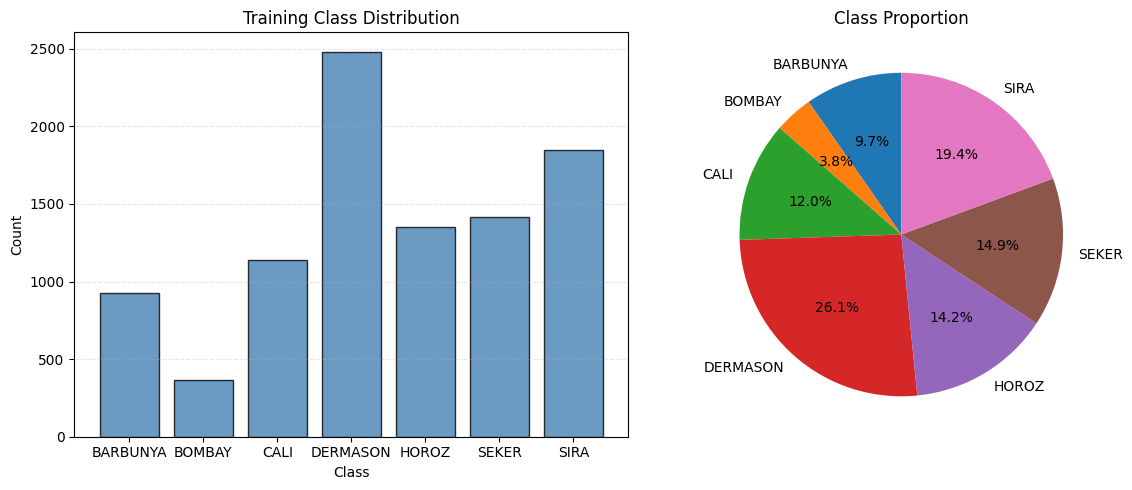

In [13]:
plot_class_distribution(
  y_train,
  class_names=target_le.classes_,
  title='Training Class Distribution',
)

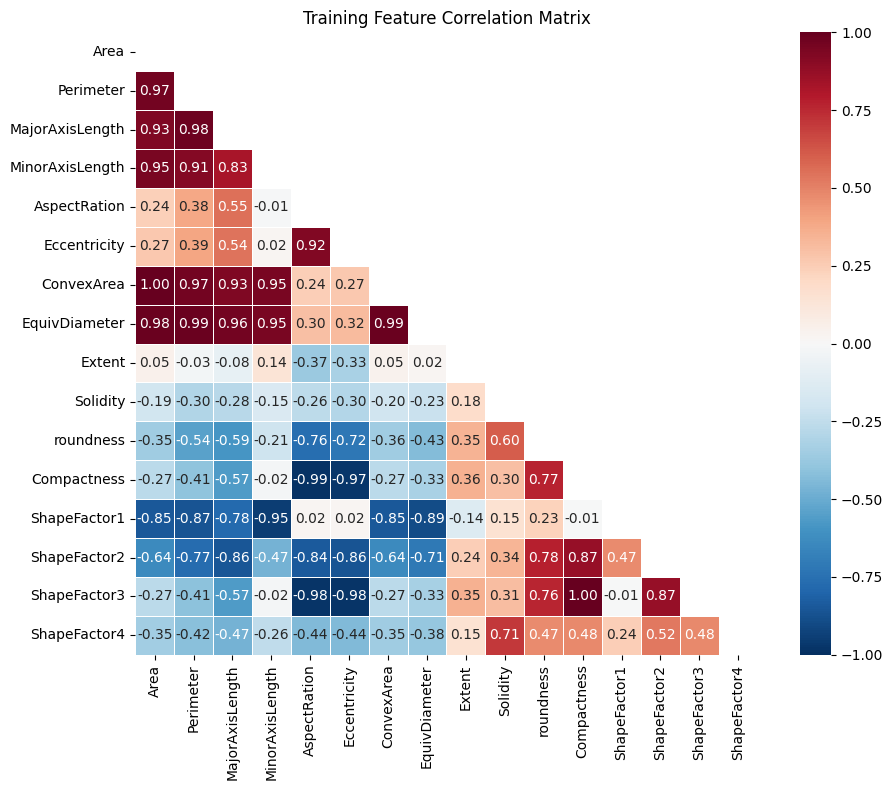

In [14]:
plot_correlation_heatmap(
  X_train,
  title='Training Feature Correlation Matrix',
)

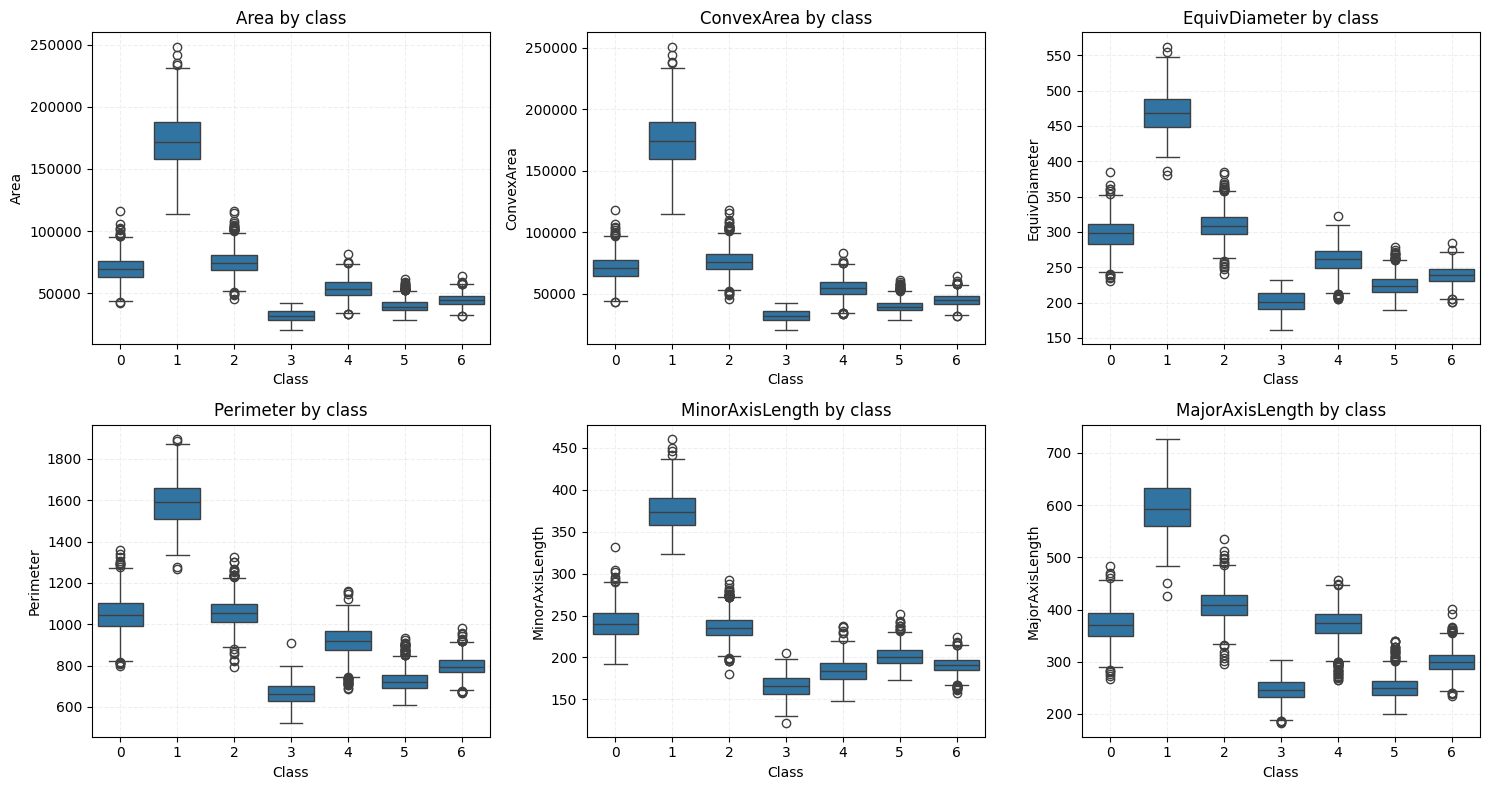

In [15]:
plot_top_feature_distributions(
  X_train,
  y_train,
  top_n=6,
)

# 3. Mô hình và huấn luyện mô hình <a id='3'></a>

In [16]:
models = {}

## 3.1 Logistic Regression (nhị phân và đa lớp)

### 3.1.1 Logistic Regression

### Co so ly thuyet cho Logistic/Softmax (tom tat)

Voi bai toan nhi phan, Logistic Regression mo hinh hoa:

$$
p(y=1\mid x)=\sigma(z),\quad z=w^Tx+b,\quad \sigma(z)=\frac{1}{1+e^{-z}}.
$$

Ham mat mat cross-entropy trung binh:

$$
\mathcal{L}(w)= -\frac{1}{N}\sum_{n=1}^N\Big[y_n\log \hat y_n + (1-y_n)\log(1-\hat y_n)\Big].
$$

Gradient va Hessian:

$$
\nabla \mathcal{L}(w)=\frac{1}{N}X^T(\hat y-y),\qquad
H=\frac{1}{N}X^TRX,\; R=\mathrm{diag}(\hat y_n(1-\hat y_n)).
$$

Do $H\succeq 0$, bai toan la loi, vi vay Newton-Raphson/IRLS co the hoi tu rat nhanh gan nghiem toi uu.

Voi bai toan da lop (Softmax):

$$
y_k(x)=\frac{\exp(a_k)}{\sum_j \exp(a_j)},\quad a_k=w_k^Tx+b_k.
$$

Voi 1 mau, Jacobian cua softmax la:

$$
\frac{\partial y_k}{\partial a_j}=y_k(\delta_{kj}-y_j).
$$

Tong quat tren toan bo mau, Hessian theo tung khoi co dang:

$$
H=\sum_{n=1}^N x_nx_n^T \otimes \left(\mathrm{Diag}(y_n)-y_ny_n^T\right),
$$

cho thay ma tran do cong duong ban xac dinh, phu hop voi toi uu hoa bang cac phuong phap gradient/Newton.

In [17]:

binary_slice = make_binary_subset(
  X_train_scaled,
  y_train,
  X_test_scaled,
  y_test,
  binary_classes=BINARY_CLASSES,
  feature_indices=BINARY_FEATURE_INDICES,
)

binary_class_0, binary_class_1 = binary_slice.class_0, binary_slice.class_1
feat_idx_0, feat_idx_1 = binary_slice.feature_indices
X_train_bin, y_train_bin = binary_slice.X_train_bin, binary_slice.y_train_bin
X_test_bin, y_test_bin = binary_slice.X_test_bin, binary_slice.y_test_bin

logreg = build_from_config(LogisticRegression, logreg_cfg)
logreg.fit(X=X_train_bin, y=y_train_bin)
models['Logistic Regression (Binary)'] = logreg

logreg_preds = logreg.predict(X=X_test_bin)
logreg_eval = logreg.evaluate(y_pred=logreg_preds, y_true=y_test_bin)
print('Logistic Regression Binary Evaluation:', logreg_eval)

Binary subset -> classes=(0, 2), features=(0, 1), train=2066, test=591
Iteration 0: Loss 0.6931
Converged at iteration 0: update norm 1.132862e-05 < eps 1.000000e-04
Logistic Regression Binary Evaluation: {'accuracy': 0.5532994923857868, 'precision': 0.7531790415555364, 'recall': 0.5532994923857868, 'f1-score': 0.3960002526654454, 'macro_avg': {'precision': 0.7762711864406779, 'recall': 0.5018867924528302, 'f1-score': 0.35965459500279084}, 'weighted_avg': {'precision': 0.7531790415555364, 'recall': 0.5532994923857868, 'f1-score': 0.3960002526654454}, 'classification_report': {'selected_average': 'weighted', 'selected': {'accuracy': 0.5532994923857868, 'precision': 0.7531790415555364, 'recall': 0.5532994923857868, 'f1-score': 0.3960002526654454}, 'macro_avg': {'accuracy': 0.5532994923857868, 'precision': 0.7762711864406779, 'recall': 0.5018867924528302, 'f1-score': 0.35965459500279084}, 'weighted_avg': {'accuracy': 0.5532994923857868, 'precision': 0.7531790415555364, 'recall': 0.5532994

Iteration 0: Loss 0.6931
Converged at iteration 0: update norm 1.132862e-05 < eps 1.000000e-04
Iteration 0: Loss 0.6931
Converged at iteration 5: step norm 3.260201e-07 < eps 1.000000e-04
GD vs Newton-IRLS on binary subset:
GD      -> iters=1, wall_time=0.0006s, f1=0.3960
Newton  -> iters=6, wall_time=0.0007s, f1=0.7476


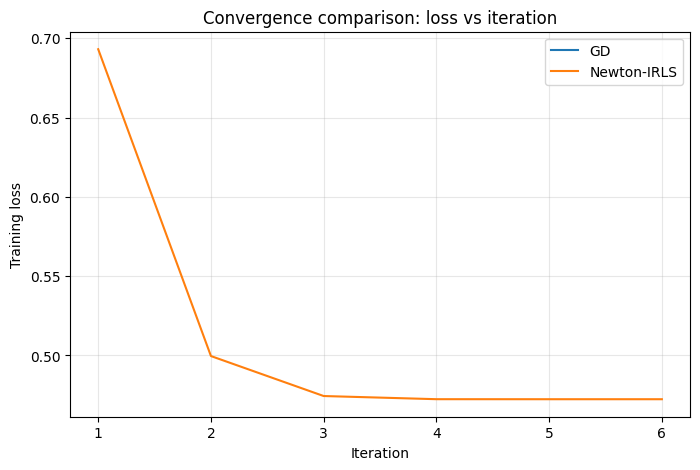

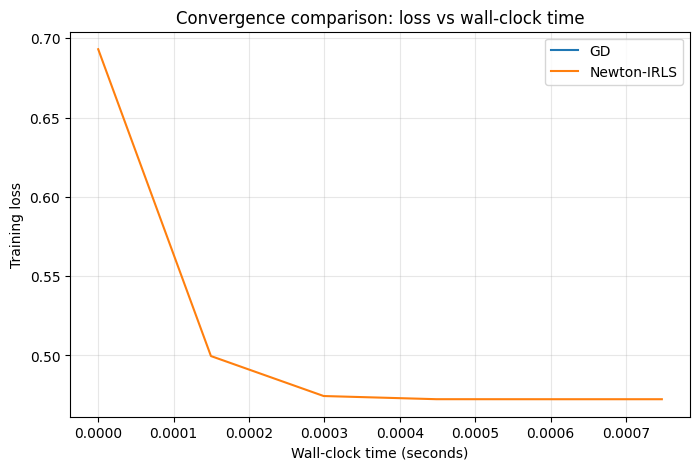

In [18]:
# Compare first-order (GD) and second-order (Newton/IRLS) optimization on the same binary task.
gd_cfg = LogisticRegressionConfig(
  learning_rate=logreg_cfg.learning_rate,
  eps=logreg_cfg.eps,
  max_iter=5000,
)
nr_cfg = LogisticRegressionConfig(
  learning_rate=logreg_cfg.learning_rate,
  eps=logreg_cfg.eps,
  max_iter=5000,
)

logreg_gd = build_from_config(LogisticRegression, gd_cfg)
t0 = time.perf_counter()
logreg_gd.fit(X_train_bin, y_train_bin, solver='gradient_descent')
gd_time = time.perf_counter() - t0

auto_nr = build_from_config(LogisticRegression, nr_cfg)
t0 = time.perf_counter()
auto_nr.fit(X_train_bin, y_train_bin, solver='newton_raphson')
nr_time = time.perf_counter() - t0

gd_report = classification_report(logreg_gd.predict(X_test_bin), y_test_bin)
nr_report = classification_report(auto_nr.predict(X_test_bin), y_test_bin)

print('GD vs Newton-IRLS on binary subset:')
print(f"GD      -> iters={len(logreg_gd.loss_history_)}, wall_time={gd_time:.4f}s, f1={gd_report['f1-score']:.4f}")
print(f"Newton  -> iters={len(auto_nr.loss_history_)}, wall_time={nr_time:.4f}s, f1={nr_report['f1-score']:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, len(logreg_gd.loss_history_) + 1), logreg_gd.loss_history_, label='GD')
plt.plot(np.arange(1, len(auto_nr.loss_history_) + 1), auto_nr.loss_history_, label='Newton-IRLS')
plt.xlabel('Iteration')
plt.ylabel('Training loss')
plt.title('Convergence comparison: loss vs iteration')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Approximate loss-vs-time by spreading total fit time across iterations.
gd_time_axis = np.linspace(0.0, gd_time, len(logreg_gd.loss_history_))
nr_time_axis = np.linspace(0.0, nr_time, len(auto_nr.loss_history_))

plt.figure(figsize=(8, 5))
plt.plot(gd_time_axis, logreg_gd.loss_history_, label='GD')
plt.plot(nr_time_axis, auto_nr.loss_history_, label='Newton-IRLS')
plt.xlabel('Wall-clock time (seconds)')
plt.ylabel('Training loss')
plt.title('Convergence comparison: loss vs wall-clock time')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### 3.1.2 Các chiến thuật khi phân lớp đa lớp
- One-vs-Rest (OvR)
- One-vs-One (OvO)
- Softmax Regression (Multinomial Logistic Regression)

In [19]:
print('So sánh các chiến thuật đa lớp: OvR, OvO, Softmax')

So sánh các chiến thuật đa lớp: OvR, OvO, Softmax


In [20]:
ovr_preds, ovr_models = ovr_predict_with_logistic(
  X_train_scaled,
  y_train,
  X_test_scaled,
  logreg_cfg.learning_rate,
  logreg_cfg.eps,
  logreg_cfg.max_iter,
)
ovr_metrics = evaluate_multiclass_strategy(y_test, ovr_preds, 'One-vs-Rest (OvR)')

Iteration 0: Loss 0.6931
Converged at iteration 0: update norm 4.770774e-05 < eps 1.000000e-04
Iteration 0: Loss 0.6931
Converged at iteration 0: update norm 5.937781e-05 < eps 1.000000e-04
Iteration 0: Loss 0.6931
Converged at iteration 0: update norm 5.349294e-05 < eps 1.000000e-04
Iteration 0: Loss 0.6931
Converged at iteration 0: update norm 7.082517e-05 < eps 1.000000e-04
Iteration 0: Loss 0.6931
Converged at iteration 0: update norm 6.545625e-05 < eps 1.000000e-04
Iteration 0: Loss 0.6931
Converged at iteration 0: update norm 6.984900e-05 < eps 1.000000e-04
Iteration 0: Loss 0.6931
Converged at iteration 0: update norm 3.388703e-05 < eps 1.000000e-04
[One-vs-Rest (OvR)] Accuracy: 0.6743
precision=0.7348, recall=0.6743, f1-score=0.5847


In [21]:
ovo_preds, ovo_models = ovo_predict_with_logistic(
  X_train_scaled,
  y_train,
  X_test_scaled,
  logreg_cfg.learning_rate,
  logreg_cfg.eps,
  logreg_cfg.max_iter,
)
ovo_metrics = evaluate_multiclass_strategy(y_test, ovo_preds, 'One-vs-One (OvO)')

Iteration 0: Loss 0.6931
Converged at iteration 0: update norm 9.275855e-05 < eps 1.000000e-04
Iteration 0: Loss 0.6931
Converged at iteration 0: update norm 6.102208e-05 < eps 1.000000e-04
Iteration 0: Loss 0.6931
Iteration 100: Loss 0.6773
Iteration 200: Loss 0.6620
Iteration 300: Loss 0.6472
Iteration 400: Loss 0.6330
Iteration 500: Loss 0.6192
Iteration 600: Loss 0.6060
Iteration 700: Loss 0.5932
Iteration 800: Loss 0.5808
Iteration 900: Loss 0.5689
Iteration 1000: Loss 0.5574
Iteration 1100: Loss 0.5463
Iteration 1200: Loss 0.5355
Iteration 1300: Loss 0.5252
Converged at iteration 1356: update norm 9.998790e-05 < eps 1.000000e-04
Iteration 0: Loss 0.6931
Iteration 100: Loss 0.6797
Iteration 200: Loss 0.6669
Iteration 300: Loss 0.6545
Iteration 400: Loss 0.6427
Iteration 500: Loss 0.6313
Iteration 600: Loss 0.6204
Iteration 700: Loss 0.6099
Converged at iteration 770: update norm 9.998204e-05 < eps 1.000000e-04
Iteration 0: Loss 0.6931
Iteration 100: Loss 0.6711
Iteration 200: Loss

In [22]:
softmax_model = build_from_config(SoftmaxRegression, softmax_cfg)
softmax_model.fit(X_train_scaled, y_train)

softmax_preds = softmax_model.predict(X_test_scaled)
softmax_metrics = evaluate_multiclass_strategy(
  y_test,
  softmax_preds,
  'Softmax Regression (Multinomial)',
)

if 'models' not in globals():
  models = {}
models['Softmax Regression'] = softmax_model

Iteration 0: Loss 1.9459
Iteration 100: Loss 1.9310
Iteration 200: Loss 1.9164
Iteration 300: Loss 1.9021
Iteration 400: Loss 1.8880
Iteration 500: Loss 1.8743
Iteration 600: Loss 1.8608
Iteration 700: Loss 1.8476
Iteration 800: Loss 1.8346
Iteration 900: Loss 1.8219
Iteration 1000: Loss 1.8095
Iteration 1100: Loss 1.7972
Iteration 1200: Loss 1.7852
Iteration 1300: Loss 1.7735
Iteration 1400: Loss 1.7619
Iteration 1500: Loss 1.7506
Iteration 1600: Loss 1.7395
Iteration 1700: Loss 1.7285
Iteration 1800: Loss 1.7178
Iteration 1900: Loss 1.7073
Iteration 2000: Loss 1.6969
Iteration 2100: Loss 1.6867
Converged at iteration 2144: update norm 9.999481e-05 < eps 1.000000e-04
[Softmax Regression (Multinomial)] Accuracy: 0.6794
precision=0.7371, recall=0.6794, f1-score=0.5939


In [23]:
strategy_results_df = pd.DataFrame([
  ovr_metrics,
  ovo_metrics,
  softmax_metrics,
]).set_index('strategy')

print('Comparison of multiclass classification strategies:')
strategy_results_df.sort_values('accuracy', ascending=False)

Comparison of multiclass classification strategies:


,accuracy,precision,recall,f1-score
strategy,,,,
Softmax Regression (Multinomial),0.679398,0.737076,0.679398,0.593901
One-vs-One (OvO),0.675725,0.735209,0.675725,0.587405
One-vs-Rest (OvR),0.674256,0.734768,0.674256,0.584711


### 3.1.3 Laplace Approximation (Bayesian Logistic Regression)

In [24]:
blr = build_from_config(LogisticRegression, logreg_cfg)
blr.fit(X=X_train_bin, y=y_train_bin, solver='laplace_approximation')

models['Bayesian Logistic Regression (Laplace)'] = blr

blr_preds = blr.predict(X=X_test_bin)
blr_eval = blr.evaluate(y_pred=blr_preds, y_true=y_test_bin)
blr_acc = blr_eval['accuracy']
print(f'Bayesian Logistic Regression (Laplace Approximation) accuracy: {blr_acc:.4f}')

Iteration 0: MAP objective 0.7153
Converged at iteration 4: step norm 9.288760e-08 < eps 1.000000e-04
Bayesian Logistic Regression (Laplace Approximation) accuracy: 0.7597


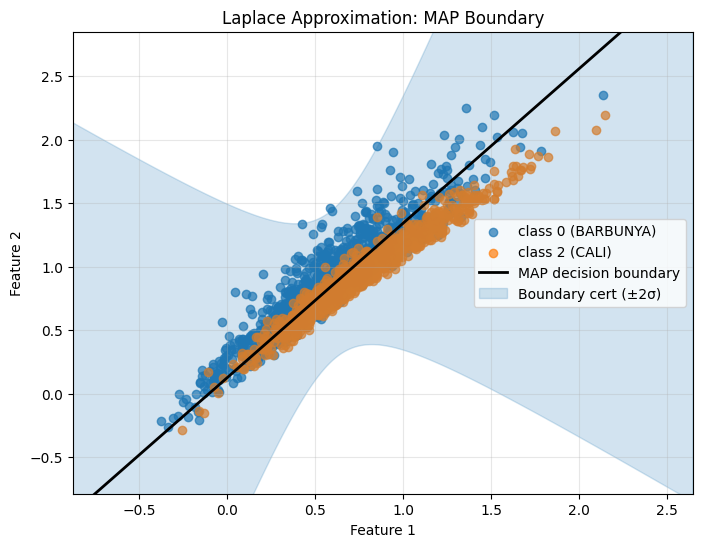

In [25]:
# 1) MAP parameters from the fitted Bayesian logistic regression
theta_map = blr.theta.copy()                    
X_aug = blr._augment(X_train_bin)            
y_binary = (y_train_bin == blr.classes_[1]).astype(float)

logits_map = X_aug @ theta_map
probs_map = 1.0 / (1.0 + np.exp(-np.clip(logits_map, -500, 500)))
W_diag = probs_map * (1.0 - probs_map)

n_samples = X_aug.shape[0]
prior_mask = blr._prior_mask(X_aug.shape[1])
reg = blr.prior_precision / n_samples

H_map = (X_aug.T * W_diag) @ X_aug / n_samples
H_map += reg * np.diag(prior_mask)
H_map += 1e-8 * np.eye(X_aug.shape[1])

posterior_cov = np.linalg.pinv(H_map)
posterior_cov = 0.5 * (posterior_cov + posterior_cov.T)
posterior_mean = theta_map

w1, w2, b = posterior_mean
if np.isclose(w2, 0.0):
    print("w2 near zero, skipping 2D plot")
else:
    x_grid = np.linspace(X_train_bin[:, 0].min() - 0.5, X_train_bin[:, 0].max() + 0.5, 400)
    y_boundary_mean = -(b + w1 * x_grid) / w2

    grads = np.column_stack([
        -x_grid / w2,
        (b + w1 * x_grid) / (w2 ** 2),
        -np.ones_like(x_grid) / w2,
    ])
    boundary_var = np.einsum('bi,ij,bj->b', grads, posterior_cov, grads)
    boundary_var = np.maximum(boundary_var, 0.0)
    boundary_std = np.sqrt(boundary_var)

    y_upper = y_boundary_mean + 2.0 * boundary_std
    y_lower = y_boundary_mean - 2.0 * boundary_std

    plt.figure(figsize=(8, 6))
    plt.scatter(
        X_train_bin[y_train_bin == blr.classes_[0], 0],
        X_train_bin[y_train_bin == blr.classes_[0], 1],
        label=f"class {blr.classes_[0]} ({target_le.classes_[blr.classes_[0]]})", alpha=0.7,
    )
    plt.scatter(
        X_train_bin[y_train_bin == blr.classes_[1], 0],
        X_train_bin[y_train_bin == blr.classes_[1], 1],
        label=f"class {blr.classes_[1]} ({target_le.classes_[blr.classes_[1]]})", alpha=0.7,
    )
    plt.plot(x_grid, y_boundary_mean, color='black', linewidth=2, label='MAP decision boundary')
    plt.fill_between(x_grid, y_lower, y_upper, color='tab:blue', alpha=0.2, label='Boundary cert (±2σ)')
    plt.xlim(x_grid.min(), x_grid.max())
    plt.ylim(X_train_bin[:, 1].min() - 0.5, X_train_bin[:, 1].max() + 0.5)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title('Laplace Approximation: MAP Boundary')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


## 3.2 Linear Discriminant Analysis - LDA và QDA

### 3.2.1 LDA và QDA

Tóm tắt lý thuyết cốt lõi:

- **LDA (Linear Discriminant Analysis)** giả thiết các lớp Gaussian có **cùng ma trận hiệp phương sai** $\Sigma$, nên hàm phân biệt theo Bayes có dạng tuyến tính theo $x$.
- **QDA (Quadratic Discriminant Analysis)** cho phép mỗi lớp có $\Sigma_k$ riêng, vì vậy biên quyết định có dạng bậc hai (phi tuyến trong không gian đầu vào).
- Đánh đổi chính: LDA có ít tham số hơn nên thường ổn định hơn khi dữ liệu ít hoặc chiều lớn; QDA linh hoạt hơn nhưng dễ overfit nếu số mẫu mỗi lớp không đủ lớn.

Về mặt ước lượng:
- LDA: ước lượng $\mu_k$, prior $\pi_k$, và một $\Sigma$ dùng chung.
- QDA: ước lượng $\mu_k$, $\pi_k$, và $\Sigma_k$ cho từng lớp.


#### LDA

In [26]:
lda = build_from_config(LDA, lda_cfg)
lda.fit(X=X_train_scaled, y=y_train)

models['LDA'] = lda

lda_preds = lda.predict(X=X_test_scaled)
lda_eval = lda.evaluate(y_pred=lda_preds, y_true=y_test)
lda_acc = lda_eval['accuracy']
print(f'LDA accuracy: {lda_acc:.4f}')

LDA accuracy: 0.9005


#### QDA

In [27]:
qda = build_from_config(QDA, qda_cfg)
qda.fit(X=X_train_scaled, y=y_train)

models['QDA'] = qda

qda_preds = qda.predict(X=X_test_scaled)
qda_eval = qda.evaluate(y_pred=qda_preds, y_true=y_test)
qda_acc = qda_eval['accuracy']
print(f'QDA accuracy: {qda_acc:.4f}')

QDA accuracy: 0.9071


### 3.2.2 Fisher ratio feature ranking

Với mỗi đặc trưng $x_j$, ta xem hướng chiếu chỉ chọn đúng tọa độ đó, khi đó tiêu chuẩn Fisher trở thành

$$
J(w_j) = J_j = \frac{\sum_{c=1}^{C} n_c (\mu_{c,j} - \mu_j)^2}{\sum_{c=1}^{C} n_c \, \sigma_{c,j}^2}
$$

Trong đó $n_c$ là số mẫu huấn luyện của lớp $c$, $\mu_{c,j}$ và $\sigma_{c,j}^2$ lần lượt là trung bình và phương sai của đặc trưng $j$ trong lớp $c$, còn $\mu_j$ là trung bình toàn cục của đặc trưng $j$. Giá trị $J_j$ càng lớn thì đặc trưng đó càng phân tách lớp tốt so với độ phân tán trong từng lớp.

In [28]:
# Fisher ratio cho từng đặc trưng (bài toán đa lớp)
fisher_df = fisher_ratio_ranking(
  X_train_df=X_train,
  X_train_scaled=X_train_scaled,
  y_train=y_train,
)

print('Bảng xếp hạng Fisher ratio (càng cao càng tốt):')
fisher_df

Bảng xếp hạng Fisher ratio (càng cao càng tốt):


,feature,fisher_ratio
0,Area,13.038658
1,ConvexArea,13.023622
2,EquivDiameter,11.314876
3,Perimeter,10.791494
4,MinorAxisLength,10.005911
5,MajorAxisLength,9.528009
6,ShapeFactor1,5.375710
7,ShapeFactor2,5.322083
8,AspectRation,4.461345
9,Compactness,4.374068


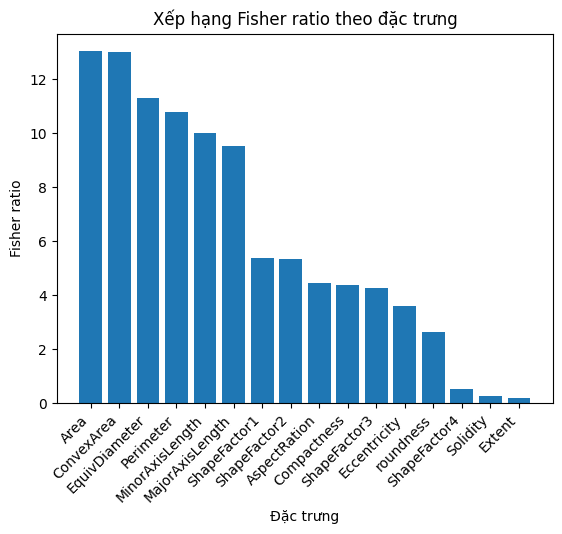

In [29]:
plt.bar(fisher_df['feature'], fisher_df['fisher_ratio'])
plt.xlabel('Đặc trưng')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Fisher ratio')
plt.title('Xếp hạng Fisher ratio theo đặc trưng')

plt.show()

### 3.2.3 Vẽ quy chiếu LDA xuống 2D và biểu diễn đường quyết định

LDA 2D projection captures about 0.7599 of the discriminative eigenvalue mass.


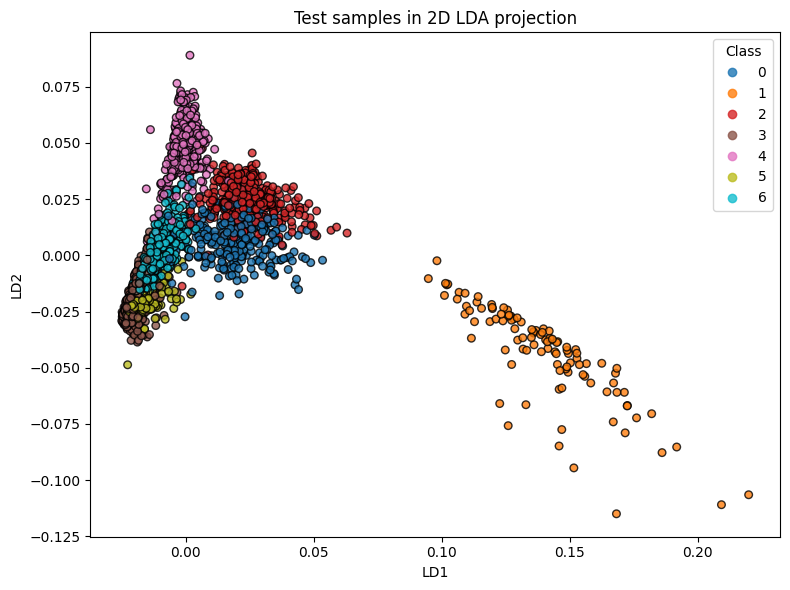

In [30]:
# Project the data to 2D using the LDA model projection methods
lda_projection = build_from_config(LDA, lda_cfg)
X_train_lda_2d = lda_projection.fit_transform(X_train_scaled, y_train, n_components=2)
X_test_lda_2d = lda_projection.transform(X_test_scaled, n_components=2)
explained_ratio = lda_projection.explained_discriminative_ratio(n_components=2)
print(f'LDA 2D projection captures about {explained_ratio.sum():.4f} of the discriminative eigenvalue mass.')

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
  X_test_lda_2d[:, 0],
  X_test_lda_2d[:, 1],
  c=y_test,
  cmap='tab10',
  alpha=0.8,
  edgecolor='k',
  s=30,
)
plt.title('Test samples in 2D LDA projection')
plt.xlabel('LD1')
plt.ylabel('LD2')
plt.legend(*scatter.legend_elements(), title='Class', loc='best')
plt.tight_layout()
plt.show()

LDA accuracy on 2D projected space: 0.7297


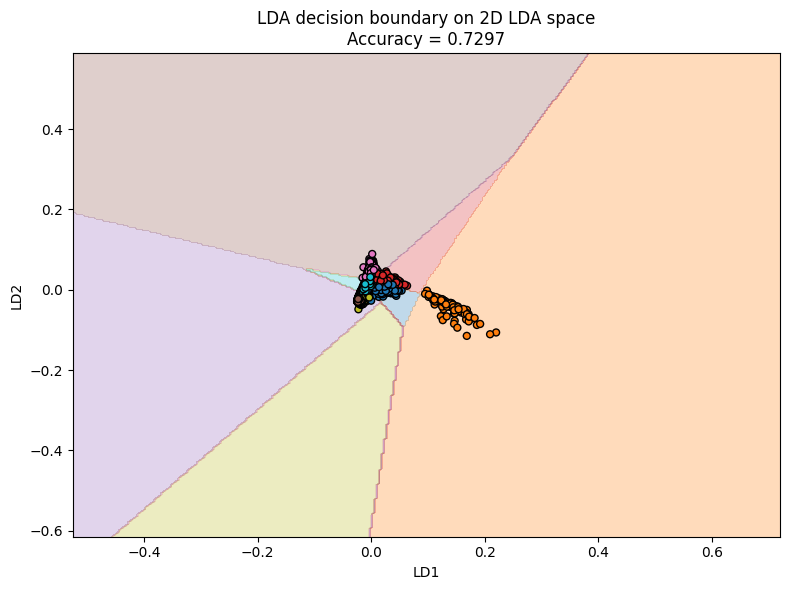

In [31]:
# Fit LDA on the 2D projected space and draw its decision boundary
lda_2d = build_from_config(LDA, lda_cfg)
lda_2d.fit(X_train_lda_2d, y_train)
lda_2d_preds_2d = lda_2d.predict(X_test_lda_2d)
lda_eval_2d = lda_2d.evaluate(lda_2d_preds_2d, y_test)
lda_acc_2d = lda_eval_2d['accuracy']
print(f'LDA accuracy on 2D projected space: {lda_acc_2d:.4f}')

all_points = np.vstack([X_train_lda_2d, X_test_lda_2d])
x_min, x_max = all_points[:, 0].min() - 0.5, all_points[:, 0].max() + 0.5
y_min, y_max = all_points[:, 1].min() - 0.5, all_points[:, 1].max() + 0.5
xx, yy = np.meshgrid(
  np.linspace(x_min, x_max, 300),
  np.linspace(y_min, y_max, 300),
)
grid = np.c_[xx.ravel(), yy.ravel()]
lda_grid = lda_2d.predict(grid).reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, lda_grid, alpha=0.28, cmap='tab10')
plt.scatter(
  X_test_lda_2d[:, 0],
  X_test_lda_2d[:, 1],
  c=y_test,
  cmap='tab10',
  edgecolor='k',
  s=25,
)
plt.title(f'LDA decision boundary on 2D LDA space\nAccuracy = {lda_acc_2d:.4f}')
plt.xlabel('LD1')
plt.ylabel('LD2')
plt.tight_layout()
plt.show()

### 3.2.4 Khi nào LDA tốt hơn QDA và ngược lại

**Khi LDA thường tốt hơn**

- LDA giả định mọi lớp dùng chung một ma trận hiệp phương sai, nên số tham số cần ước lượng ít hơn QDA. Điều này thường làm LDA ổn định hơn khi dữ liệu không quá lớn hoặc số chiều đặc trưng tương đối cao.
- Nếu các lớp chủ yếu khác nhau ở trung bình, trong khi độ phân tán và hướng phân bố tương tự nhau, biên tuyến tính của LDA thường đủ tốt và tổng quát hóa tốt hơn.
- LDA cũng ít bị quá khớp hơn khi một số lớp có ít mẫu huấn luyện.

**Khi QDA thường tốt hơn**

- QDA cho phép mỗi lớp có ma trận hiệp phương sai riêng, nên phù hợp hơn khi các lớp có độ phân tán, hình dạng hoặc hướng khác nhau rõ rệt.
- Nếu biên phân lớp là phi tuyến, QDA có thể mô hình hóa tốt hơn do bề mặt quyết định là bậc hai.
- Khi mỗi lớp có đủ dữ liệu để ước lượng hiệp phương sai tin cậy, QDA có thể tận dụng độ linh hoạt bổ sung để vượt LDA.

**Cách đọc các đồ thị trong notebook này**

- Phép chiếu LDA xuống 2D giữ lại hai hướng phân biệt mạnh nhất, nên cho góc nhìn trực quan rõ nhất về khả năng tách lớp.
- Nếu biên LDA đã bám sát vùng lớp quan sát được, thì giả định hiệp phương sai chung có khả năng là hợp lý.
- Nếu biên QDA khớp tốt hơn các cụm quan sát được, đặc biệt ở vùng cong hoặc mật độ không đều, thì hiệp phương sai riêng theo lớp có thể là yếu tố quan trọng và QDA sẽ phù hợp hơn.
- Nếu QDA tạo biên phức tạp hơn nhưng độ chính xác không tăng đáng kể, thì độ linh hoạt bổ sung đó có thể không cần thiết và LDA là lựa chọn an toàn hơn.

### 3.2.5 Gaussian Naive Bayes (giả thiết độc lập) với LDA

In [32]:
gnb = build_from_config(GaussianNaiveBayes, gnb_cfg)
gnb.fit(X=X_train_scaled, y=y_train)
gnb_preds = gnb.predict(X=X_test_scaled)
gnb_eval = gnb.evaluate(gnb_preds, y_test)
gnb_acc = gnb_eval['accuracy']
print(f'Gaussian Naive Bayes accuracy: {gnb_acc:.4f}')

models['Gaussian Naive Bayes'] = gnb

Gaussian Naive Bayes accuracy: 0.8990


## 3.3 Perceptron và Logistic Regression có Regularization

Khung lý thuyết ngắn:

- **Perceptron** cập nhật trọng số trên các điểm phân loại sai, phù hợp với mục tiêu tìm siêu phẳng tách tuyến tính.
- Định lý hội tụ Perceptron: nếu dữ liệu tách tuyến tính, thuật toán hội tụ sau hữu hạn bước; nếu không tách tuyến tính, loss dao động và không thể về 0 hoàn toàn.
- **Logistic Regression + regularization** dùng cross-entropy kèm penalty để kiểm soát độ phức tạp mô hình.

Vai trò của regularization:
- **L1**: tạo nghiệm thưa (sparse), hỗ trợ chọn đặc trưng.
- **L2**: làm trơn nghiệm, giảm phương sai, thường ổn định hơn khi đặc trưng tương quan cao.
- **Class-weighted loss**: tăng trọng số lớp thiểu số để giảm thiên lệch trên dữ liệu mất cân bằng.


In [33]:
perceptron_clf = build_from_config(Perceptron, perceptron_cfg)
perceptron_clf.fit(X_train_bin, y_train_bin)

print('Perceptron Report on Binary Dry Bean Subset:')
print(classification_report(perceptron_clf.predict(X_test_bin), y_test_bin))

models['Perceptron (Binary)'] = perceptron_clf

Perceptron Report on Binary Dry Bean Subset:
{'accuracy': 0.7597292724196277, 'precision': 0.7627685279271212, 'recall': 0.7597292724196277, 'f1-score': 0.7560034382563187}


Converged at epoch 1
Perceptron on toy datasets:
Linearly separable -> epochs=2, accuracy=1.0000
XOR-like (non-separable) -> epochs=5000, accuracy=0.3625


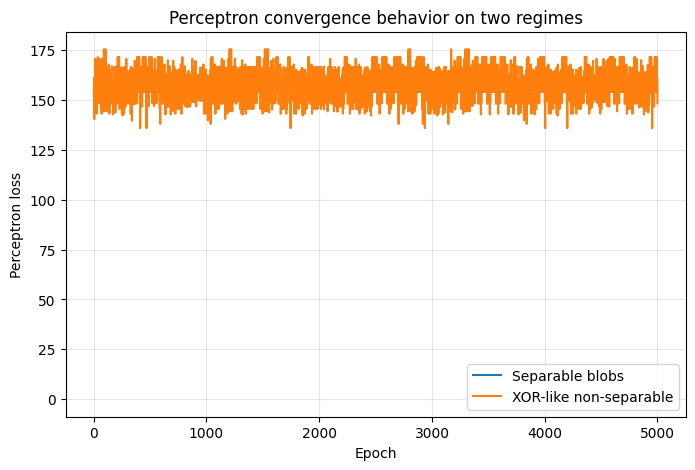

In [34]:
# Perceptron convergence behavior on linearly separable vs non-separable toy datasets.
toy_results = run_perceptron_toy_convergence(
  seed=SEED,
  n_toy=240,
  learning_rate=1.0,
  max_iter=5000,
)

print('Perceptron on toy datasets:')
print(
  f"Linearly separable -> epochs={toy_results['sep_epochs']}, "
  f"accuracy={toy_results['sep_accuracy']:.4f}"
)
print(
  f"XOR-like (non-separable) -> epochs={toy_results['xor_epochs']}, "
  f"accuracy={toy_results['xor_accuracy']:.4f}"
)

plt.figure(figsize=(8, 5))
plt.plot(
  np.arange(1, len(toy_results['sep_loss_history']) + 1),
  toy_results['sep_loss_history'],
  label='Separable blobs',
)
plt.plot(
  np.arange(1, len(toy_results['xor_loss_history']) + 1),
  toy_results['xor_loss_history'],
  label='XOR-like non-separable',
)
plt.xlabel('Epoch')
plt.ylabel('Perceptron loss')
plt.title('Perceptron convergence behavior on two regimes')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [35]:
from IPython.display import display

# Tune lambda for L1/L2 using stratified 5-fold CV.
lambda_grid = [1e-5, 3e-5, 1e-4, 3e-4, 1e-3, 3e-3, 1e-2]

tuning_df, best_lambdas = tune_logistic_regularization(
  X_train_bin,
  y_train_bin,
  base_kwargs={
    'learning_rate': logreg_cfg.learning_rate,
    'eps': logreg_cfg.eps,
    'max_iter': 5000,
  },
  lambda_grid=lambda_grid,
  solvers=('l1', 'l2'),
  k=KFOLD_SPLITS,
  random_state=SEED,
)

print('Stratified 5-fold CV for lambda selection (binary task):')
display(tuning_df.sort_values(['penalty', 'cv_f1_mean'], ascending=[True, False]))

best_l1_lambda = best_lambdas['l1']
best_l2_lambda = best_lambdas['l2']
print(f"Best lambda (L1) = {best_l1_lambda}")
print(f"Best lambda (L2) = {best_l2_lambda}")

# Train final regularized models using tuned lambdas.
logreg_l1 = build_from_config(
  LogisticRegression,
  LogisticRegressionConfig(
    learning_rate=logreg_cfg.learning_rate,
    eps=logreg_cfg.eps,
    max_iter=5000,
    l1_penalty=best_l1_lambda,
  ),
)
logreg_l1.fit(X_train_bin, y_train_bin, solver='l1')

logreg_l2 = build_from_config(
  LogisticRegression,
  LogisticRegressionConfig(
    learning_rate=logreg_cfg.learning_rate,
    eps=logreg_cfg.eps,
    max_iter=5000,
    l2_penalty=best_l2_lambda,
  ),
)
logreg_l2.fit(X_train_bin, y_train_bin, solver='l2')

elastic_lambda = float(np.sqrt(best_l1_lambda * best_l2_lambda))
logreg_elastic = build_from_config(
  LogisticRegression,
  LogisticRegressionConfig(
    learning_rate=logreg_cfg.learning_rate,
    eps=logreg_cfg.eps,
    max_iter=5000,
    l1_penalty=elastic_lambda,
    l2_penalty=elastic_lambda,
  ),
)
logreg_elastic.fit(X_train_bin, y_train_bin, solver='elastic_net')

# Class-weighted loss for imbalance handling.
logreg_l2_balanced = build_from_config(
  LogisticRegression,
  LogisticRegressionConfig(
    learning_rate=logreg_cfg.learning_rate,
    eps=logreg_cfg.eps,
    max_iter=5000,
    l2_penalty=best_l2_lambda,
    class_weight='balanced',
  ),
)
logreg_l2_balanced.fit(X_train_bin, y_train_bin, solver='l2')

logreg_l2_preds = logreg_l2.predict(X_test_bin)
logreg_l2_balanced_preds = logreg_l2_balanced.predict(X_test_bin)

regularized_models = {
  'L1': logreg_l1,
  'L2': logreg_l2,
  'Elastic Net': logreg_elastic,
  'L2 (class-weighted)': logreg_l2_balanced,
}

for reg_name, reg_model in regularized_models.items():
  reg_preds = reg_model.predict(X_test_bin)
  reg_report = classification_report(reg_preds, y_test_bin)
  print(f'Logistic Regression ({reg_name}) Report on Binary Dry Bean Subset:')
  print(reg_report)
  print(f"  sparsity_ratio(|w|<1e-3): {sparsity_ratio(reg_model.theta):.4f}")

models['Logistic Regression (Binary, L1)'] = logreg_l1
models['Logistic Regression (Binary, L2)'] = logreg_l2
models['Logistic Regression (Binary, Elastic Net)'] = logreg_elastic
models['Logistic Regression (Binary, L2, class-weighted)'] = logreg_l2_balanced

Iteration 0 (L1): Loss 0.6931
Converged at iteration 0: update norm 1.119547e-05 < eps 1.000000e-04
Iteration 0 (L1): Loss 0.6931
Converged at iteration 0: update norm 1.094108e-05 < eps 1.000000e-04
Iteration 0 (L1): Loss 0.6931
Converged at iteration 0: update norm 1.111132e-05 < eps 1.000000e-04
Iteration 0 (L1): Loss 0.6931
Converged at iteration 0: update norm 1.161374e-05 < eps 1.000000e-04
Iteration 0 (L1): Loss 0.6931
Converged at iteration 0: update norm 1.178879e-05 < eps 1.000000e-04
Iteration 0 (L1): Loss 0.6931
Converged at iteration 0: update norm 1.119547e-05 < eps 1.000000e-04
Iteration 0 (L1): Loss 0.6931
Converged at iteration 0: update norm 1.094108e-05 < eps 1.000000e-04
Iteration 0 (L1): Loss 0.6931
Converged at iteration 0: update norm 1.111132e-05 < eps 1.000000e-04
Iteration 0 (L1): Loss 0.6931
Converged at iteration 0: update norm 1.161374e-05 < eps 1.000000e-04
Iteration 0 (L1): Loss 0.6931
Converged at iteration 0: update norm 1.178879e-05 < eps 1.000000e-04


,penalty,lambda,cv_f1_mean,cv_f1_std
0,L1,0.00001,0.392981,0.000566
1,L1,0.00003,0.392981,0.000566
2,L1,0.00010,0.392981,0.000566
3,L1,0.00030,0.392981,0.000566
4,L1,0.00100,0.392981,0.000566
5,L1,0.00300,0.392981,0.000566
6,L1,0.01000,0.392981,0.000566
7,L2,0.00001,0.392981,0.000566
8,L2,0.00003,0.392981,0.000566
9,L2,0.00010,0.392981,0.000566


Best lambda (L1) = 1e-05
Best lambda (L2) = 1e-05
Iteration 0 (L1): Loss 0.6931
Converged at iteration 0: update norm 1.132862e-05 < eps 1.000000e-04
Iteration 0 (L2): Loss 0.6931
Converged at iteration 0: update norm 1.132862e-05 < eps 1.000000e-04
Iteration 0 (Elastic Net): Loss 0.6931
Converged at iteration 0: update norm 1.132862e-05 < eps 1.000000e-04
Iteration 0 (L2): Loss 0.6931
Converged at iteration 0: update norm 4.806496e-06 < eps 1.000000e-04
Logistic Regression (L1) Report on Binary Dry Bean Subset:
{'accuracy': 0.5532994923857868, 'precision': 0.7531790415555364, 'recall': 0.5532994923857868, 'f1-score': 0.3960002526654454}
  sparsity_ratio(|w|<1e-3): 1.0000
Logistic Regression (L2) Report on Binary Dry Bean Subset:
{'accuracy': 0.5532994923857868, 'precision': 0.7531790415555364, 'recall': 0.5532994923857868, 'f1-score': 0.3960002526654454}
  sparsity_ratio(|w|<1e-3): 1.0000
Logistic Regression (Elastic Net) Report on Binary Dry Bean Subset:
{'accuracy': 0.55329949238578

## 3.4 Probit

**Probit Regression** thay sigmoid bằng hàm CDF Gaussian chuẩn $\Phi(\cdot)$:

$$
p(y=1\mid x)=\Phi(w^Tx+b).
$$

Ý nghĩa:
- Vẫn là mô hình phân lớp tuyến tính trong không gian đặc trưng, nhưng ánh xạ xác suất khác Logistic.
- Có liên hệ tự nhiên với mô hình biến ẩn Gaussian, và thường được nhắc đến như một lựa chọn thay thế logistic khi phân tích xác suất.
- Trong thực nghiệm, Probit và Logistic thường cho hiệu năng gần nhau; khác biệt chủ yếu nằm ở calibration và độ nhạy theo miền dữ liệu.


In [36]:
probit_model = build_from_config(ProbitRegression, probit_cfg)
probit_model.fit(X_train_bin, y_train_bin)

models['Probit Regression'] = probit_model
y_test_pred_probit = probit_model.predict(X_test_bin)
print(f'Probit Regression Accuracy: {np.mean(y_test_pred_probit == y_test_bin):.4f}')

Iteration 0: Loss 0.6931
Iteration 100: Loss 0.6903
Iteration 200: Loss 0.6881
Iteration 300: Loss 0.6864
Iteration 400: Loss 0.6851
Converged at iteration 468: update norm 9.999960e-05 < eps 1.000000e-04
Probit Regression Accuracy: 0.5533


## 3.5 Perceptron và KernelLogisticRegression

Lý thuyết cốt lõi cho phần so sánh phi tuyến:

- Perceptron chuẩn là mô hình tuyến tính nên bị giới hạn khi dữ liệu có cấu trúc kiểu XOR/non-linearly separable.
- **Kernel Logistic Regression** dùng kernel trick để học biên quyết định phi tuyến trong không gian gốc nhưng vẫn tối ưu theo tinh thần logistic ở không gian đặc trưng ẩn.

Trực giác:
- Nếu dữ liệu gần tuyến tính, mô hình tuyến tính đơn giản thường đủ tốt và dễ diễn giải.
- Nếu dữ liệu cong/phức tạp, kernel có thể cải thiện rõ độ chính xác, đánh đổi bằng chi phí tính toán và khó diễn giải hơn.


In [37]:
if 'perceptron_clf' not in globals():
  perceptron_clf = build_from_config(Perceptron, perceptron_cfg)
  perceptron_clf.fit(X_train_bin, y_train_bin)

perceptron_test_acc = np.mean(perceptron_clf.predict(X_test_bin) == y_test_bin)
print(f'Perceptron Accuracy on Binary Dry Bean subset: {perceptron_test_acc:.4f}')
print('Kernel Logistic Regression will be trained on the same Binary Dry Bean subset for fair comparison.')

Perceptron Accuracy on Binary Dry Bean subset: 0.7597
Kernel Logistic Regression will be trained on the same Binary Dry Bean subset for fair comparison.


### Bonus: VC dimension of linear classifiers and generalization

Với lớp bộ phân lớp tuyến tính trong $\mathbb{R}^D$ (siêu phẳng có bias), VC dimension bằng $D+1$. Điều này cho biết năng lực biểu diễn của mô hình tăng tuyến tính theo số chiều đặc trưng.

Liên hệ với structural risk minimization (SRM):
- Khi tăng số đặc trưng hoặc dùng ánh xạ đặc trưng làm $D$ lớn hơn, biên quyết định linh hoạt hơn nhưng độ phức tạp giả thuyết tăng (VC dim tăng), dễ overfitting nếu dữ liệu hữu hạn.
- Regularization (L1/L2) đóng vai trò kiểm soát độ phức tạp hiệu dụng, giúp cân bằng giữa empirical risk và capacity.
- Trong các kết quả thực nghiệm ở notebook này, các mô hình tuyến tính có regularization thường ổn định hơn trên CV so với cấu hình không regularization mạnh, phù hợp với trực giác từ SRM.


In [38]:
kernel_model = build_from_config(KernelLogisticRegression, kernel_log_cfg)
kernel_model.fit(X_train_bin, y_train_bin)

kernel_preds = kernel_model.predict(X_test_bin)
kernel_report = classification_report(kernel_preds, y_test_bin)
print('Kernel Logistic Regression Report on Binary Dry Bean Subset:')
print(kernel_report)

models['Kernel Logistic Regression (Binary)'] = kernel_model

Iteration 0: Loss 0.6932
Iteration 100: Loss 1.1744
Iteration 200: Loss 1.1567
Iteration 300: Loss 1.1395
Iteration 400: Loss 1.1244
Iteration 500: Loss 1.1111
Iteration 600: Loss 1.0993
Iteration 700: Loss 1.0886
Iteration 800: Loss 1.0789
Iteration 900: Loss 1.0700
Iteration 1000: Loss 1.0618
Iteration 1100: Loss 1.0541
Iteration 1200: Loss 1.0469
Iteration 1300: Loss 1.0402
Iteration 1400: Loss 1.0337
Iteration 1500: Loss 1.0276
Iteration 1600: Loss 1.0218
Iteration 1700: Loss 1.0162
Iteration 1800: Loss 1.0108
Iteration 1900: Loss 1.0055
Iteration 2000: Loss 1.0005
Iteration 2100: Loss 0.9955
Iteration 2200: Loss 0.9907
Iteration 2300: Loss 0.9860
Iteration 2400: Loss 0.9814
Iteration 2500: Loss 0.9768
Iteration 2600: Loss 0.9724
Iteration 2700: Loss 0.9680
Iteration 2800: Loss 0.9636
Iteration 2900: Loss 0.9593
Iteration 3000: Loss 0.9550
Iteration 3100: Loss 0.9508
Iteration 3200: Loss 0.9466
Iteration 3300: Loss 0.9424
Iteration 3400: Loss 0.9383
Iteration 3500: Loss 0.9341
Iter

# 4. Đánh giá mô hình <a id='4'></a>

Nguyên tắc đánh giá xuyên suốt:

- Không dựa vào một metric duy nhất; cần kết hợp Accuracy, Precision/Recall/F1, PR/AP, ROC/AUC và calibration.
- Đánh giá trên cùng một tập test để so sánh công bằng giữa các mô hình.
- Dùng k-fold CV để kiểm tra tính ổn định theo phép chia dữ liệu.
- Dùng kiểm định thống kê (McNemar) để tránh kết luận dựa trên chênh lệch ngẫu nhiên nhỏ.


## 4.1 Đồ thị hàm mất mát theo số vòng lặp

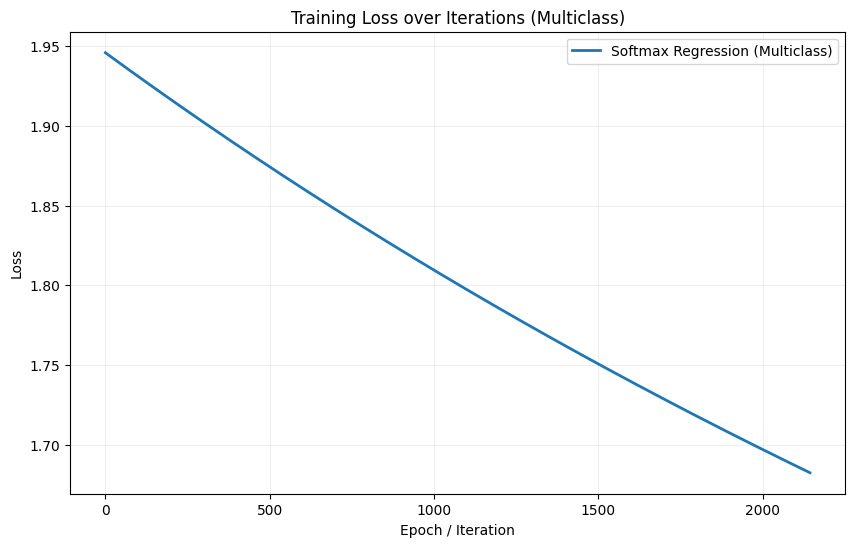

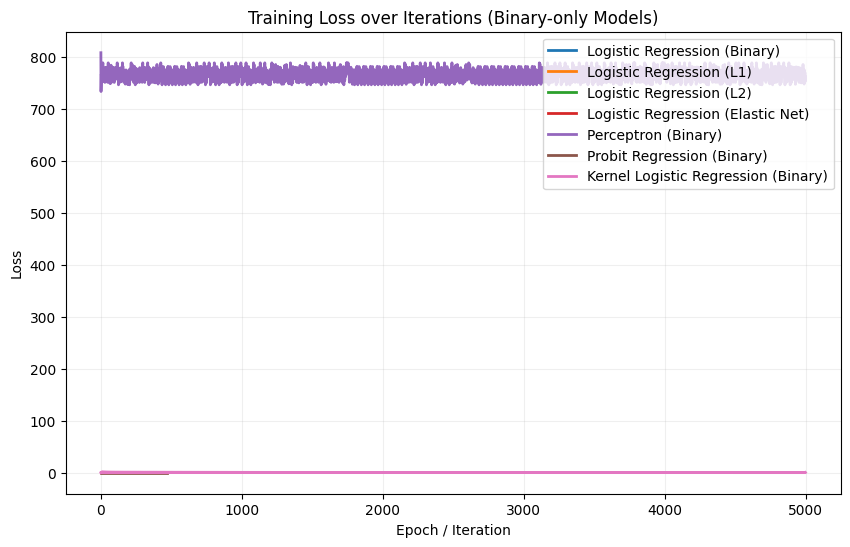

In [39]:
# Ưu tiên báo cáo loss cho bài toán đa lớp.
multiclass_loss_candidates = {
  'Softmax Regression (Multiclass)': softmax_model,
}
multiclass_models_to_plot = collect_models_with_attr(multiclass_loss_candidates, 'loss_history_')

if multiclass_models_to_plot:
  plot_loss_curves(multiclass_models_to_plot, title='Training Loss over Iterations (Multiclass)')
else:
  print('No multiclass model with loss history was found.')

# Ngoại lệ nhị phân: chỉ hiển thị cho các mô hình binary-only để tham chiếu.
binary_loss_candidates = {
  'Logistic Regression (Binary)': logreg,
  'Logistic Regression (L1)': logreg_l1,
  'Logistic Regression (L2)': logreg_l2,
  'Logistic Regression (Elastic Net)': logreg_elastic,
  'Perceptron (Binary)': perceptron_clf,
  'Probit Regression (Binary)': probit_model,
  'Kernel Logistic Regression (Binary)': kernel_model,
}
binary_models_to_plot = collect_models_with_attr(binary_loss_candidates, 'loss_history_')

if binary_models_to_plot:
  plot_loss_curves(binary_models_to_plot, title='Training Loss over Iterations (Binary-only Models)')

## 4.2 Vẽ đường ranh giới quyết định trong không gian 2D

Vẽ đường ranh giới quyết định cho tập nhị phân 2D:


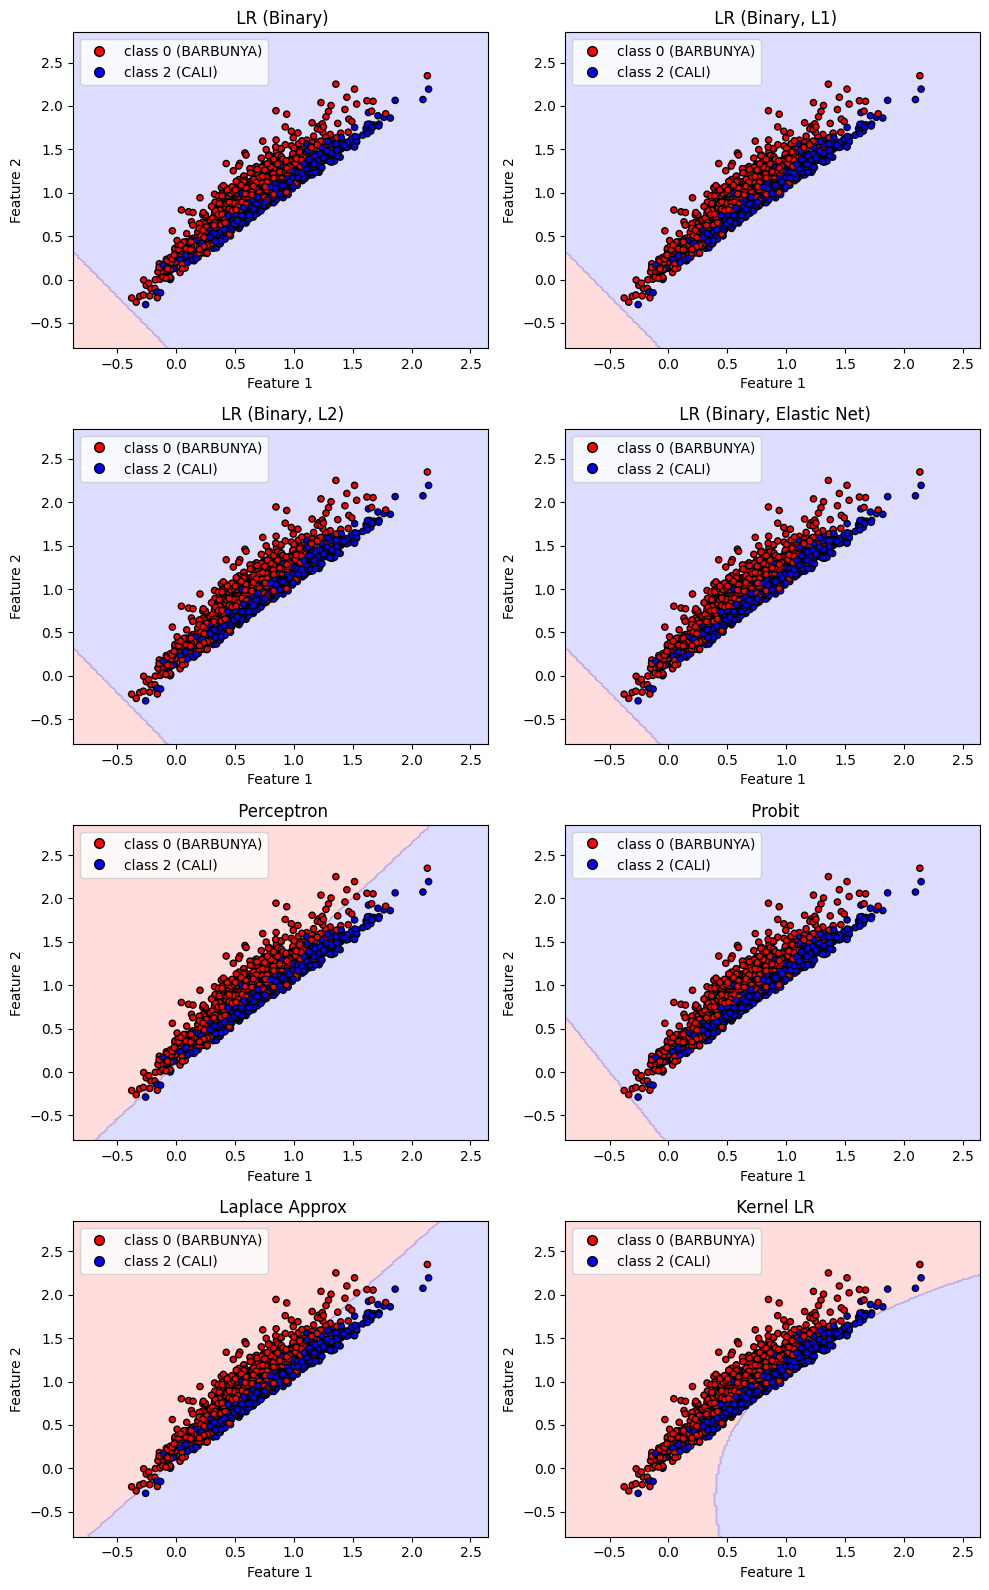

In [40]:
# Collect binary models trained on 2D space (X_train_bin) earlier.
binary_2d_candidates = {
  'LR (Binary)': logreg,
  'LR (Binary, L1)': logreg_l1,
  'LR (Binary, L2)': logreg_l2,
  'LR (Binary, Elastic Net)': logreg_elastic,
  'Perceptron': perceptron_clf,
  'Probit': probit_model,
  'Laplace Approx': blr,
  'Kernel LR': kernel_model,
}
binary_2d_models = collect_models_with_attr(binary_2d_candidates, 'predict')

if binary_2d_models:
  print('Vẽ đường ranh giới quyết định cho tập nhị phân 2D:')
  binary_class_name_map = {
    int(BINARY_CLASSES[0]): str(target_le.classes_[BINARY_CLASSES[0]]),
    int(BINARY_CLASSES[1]): str(target_le.classes_[BINARY_CLASSES[1]]),
  }

  utils_module.plot_2d_decision_boundary(
    binary_2d_models,
    X_train_bin,
    y_train_bin,
    class_name_map=binary_class_name_map,
  )
else:
  print('Không tìm thấy mô hình nhị phân 2D nào được huấn luyện trước đó.')

## 4.3 So sánh tất cả các mô hình trong một bảng kết quả thống nhất

Bảng so sánh chính (multiclass):


,model,task_type,n_classes,accuracy,precision,recall,f1-score
4,QDA,multiclass,7,0.907088,0.911746,0.907088,0.907648
3,LDA,multiclass,7,0.900477,0.912638,0.900477,0.902211
5,Gaussian Naive Bayes,multiclass,7,0.899008,0.901879,0.899008,0.899110
1,Softmax Regression,multiclass,7,0.679398,0.737076,0.679398,0.593901


Bảng tham chiếu (binary-only models, không dùng để kết luận chính cho multiclass):


,model,task_type,n_classes,accuracy,precision,recall,f1-score
2,Bayesian Logistic Regression (Laplace),binary_only,2,0.759729,0.761935,0.759729,0.756448
6,Perceptron (Binary),binary_only,2,0.759729,0.762769,0.759729,0.756003
10,"Logistic Regression (Binary, L2, class-weighted)",binary_only,2,0.568528,0.720651,0.568528,0.431795
12,Kernel Logistic Regression (Binary),binary_only,2,0.517766,0.697234,0.517766,0.427840
0,Logistic Regression (Binary),binary_only,2,0.553299,0.753179,0.553299,0.396000
8,"Logistic Regression (Binary, L2)",binary_only,2,0.553299,0.753179,0.553299,0.396000
7,"Logistic Regression (Binary, L1)",binary_only,2,0.553299,0.753179,0.553299,0.396000
9,"Logistic Regression (Binary, Elastic Net)",binary_only,2,0.553299,0.753179,0.553299,0.396000
11,Probit Regression,binary_only,2,0.553299,0.753179,0.553299,0.396000


<Figure size 800x600 with 0 Axes>

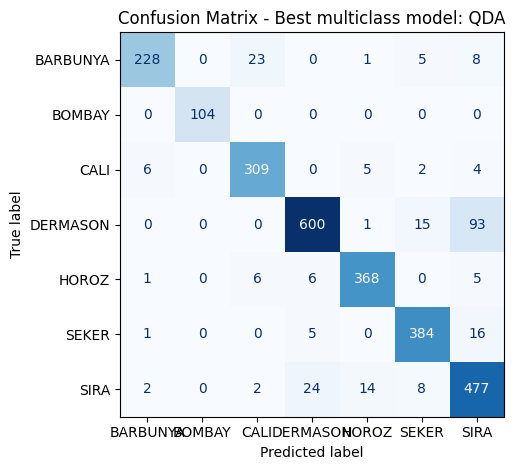

Misclassified samples for QDA: 253/2723
Top confusion pairs (true -> predicted):


,true_label,pred_label,count
0,DERMASON,SIRA,93
1,SIRA,DERMASON,24
2,BARBUNYA,CALI,23
3,SEKER,SIRA,16
4,DERMASON,SEKER,15
5,SIRA,HOROZ,14
6,SIRA,SEKER,8
7,BARBUNYA,SIRA,8
8,HOROZ,DERMASON,6
9,CALI,BARBUNYA,6


Top features with largest absolute mean shift for the hardest confusion pair:


ConvexArea         8891.988333
Area               8809.070753
Perimeter            91.525684
MajorAxisLength      36.720769
EquivDiameter        26.843932
MinorAxisLength      19.433080
AspectRation          0.041828
ShapeFactor3          0.019738
dtype: float64

In [41]:
summary_rows = []
pred_cache = {}

for model_name, model in models.items():
  if not hasattr(model, 'predict'):
    continue

  classes = np.asarray(getattr(model, 'classes_', np.array([])))
  is_binary_model = classes.shape[0] == 2
  eval_X = X_test_bin if is_binary_model else X_test_scaled
  eval_y = y_test_bin if is_binary_model else y_test

  try:
    y_pred = model.predict(eval_X)
  except Exception as e:
    print(f'Skip {model_name}: {e}')
    continue

  metrics = classification_report(y_pred, eval_y, average='weighted')
  summary_rows.append({
    'model': model_name,
    'task_type': 'binary_only' if is_binary_model else 'multiclass',
    'n_classes': int(np.unique(eval_y).shape[0]),
    'accuracy': metrics['accuracy'],
    'precision': metrics['precision'],
    'recall': metrics['recall'],
    'f1-score': metrics['f1-score'],
  })
  pred_cache[model_name] = (eval_y, y_pred)

results_df = pd.DataFrame(summary_rows)

multiclass_df = results_df[results_df['task_type'] == 'multiclass'].sort_values('f1-score', ascending=False)
print('Bảng so sánh chính (multiclass):')
display(multiclass_df)

binary_df = results_df[results_df['task_type'] == 'binary_only'].sort_values('f1-score', ascending=False)
if binary_df.shape[0] > 0:
  print('Bảng tham chiếu (binary-only models, không dùng để kết luận chính cho multiclass):')
  display(binary_df)

# Confusion matrix cho mô hình multiclass tốt nhất.
if multiclass_df.shape[0] > 0:
  best_mc_name = multiclass_df.iloc[0]['model']
  y_true_mc, y_pred_mc = pred_cache[best_mc_name]
  labels_mc = np.unique(y_true_mc)

  cm = confusion_matrix(y_true_mc, y_pred_mc, labels=labels_mc)
  plt.figure(figsize=(8, 6))
  disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_le.classes_)
  disp.plot(cmap='Blues', values_format='d', colorbar=False)
  plt.title(f'Confusion Matrix - Best multiclass model: {best_mc_name}')
  plt.tight_layout()
  plt.show()

  mis_idx = np.where(y_true_mc != y_pred_mc)[0]
  print(f'Misclassified samples for {best_mc_name}: {mis_idx.size}/{y_true_mc.shape[0]}')

  if mis_idx.size > 0:
    error_pairs = pd.DataFrame({
      'true': y_true_mc[mis_idx],
      'pred': y_pred_mc[mis_idx],
    })
    pair_counts = (
      error_pairs
      .value_counts()
      .reset_index(name='count')
      .sort_values('count', ascending=False)
    )

    pair_counts['true_label'] = target_le.inverse_transform(pair_counts['true'].astype(int))
    pair_counts['pred_label'] = target_le.inverse_transform(pair_counts['pred'].astype(int))

    print('Top confusion pairs (true -> predicted):')
    display(pair_counts[['true_label', 'pred_label', 'count']].head(10))

    if isinstance(X_test, pd.DataFrame):
      X_test_df = X_test.reset_index(drop=True)
    else:
      X_test_df = pd.DataFrame(X_test, columns=[f'feature_{i}' for i in range(X_test.shape[1])])

    top_pair_true = int(pair_counts.iloc[0]['true'])
    top_pair_pred = int(pair_counts.iloc[0]['pred'])

    pair_mask = (y_true_mc == top_pair_true) & (y_pred_mc == top_pair_pred)
    correct_mask_same_true = (y_true_mc == top_pair_true) & (y_pred_mc == y_true_mc)

    if np.any(pair_mask) and np.any(correct_mask_same_true):
      mean_diff = (
        X_test_df.loc[np.where(pair_mask)[0]].mean()
        - X_test_df.loc[np.where(correct_mask_same_true)[0]].mean()
      )
      print('Top features with largest absolute mean shift for the hardest confusion pair:')
      display(mean_diff.abs().sort_values(ascending=False).head(8))
else:
  print('No multiclass model available for confusion matrix plotting.')

## 4.4 k-fold cross-validation (k=5) và báo cáo $\text{mean} \pm \text{std}$ cho mỗi chỉ số

In [42]:
retrained_models = {
  'Softmax Regression': lambda: build_from_config(SoftmaxRegression, softmax_cfg),
  'LDA': lambda: build_from_config(LDA, lda_cfg),
  'QDA': lambda: build_from_config(QDA, qda_cfg),
  'Gaussian Naive Bayes': lambda: build_from_config(GaussianNaiveBayes, gnb_cfg),
}

metric_order = ['accuracy', 'precision', 'recall', 'f1-score']
cv_rows = []

for model_name, builder in retrained_models.items():
  result = kfold_cross_val_score(
    model=builder(),
    X=X_train_scaled,
    y=y_train,
    k=KFOLD_SPLITS,
    average='weighted',
    random_state=SEED,
    shuffle=True,
    model_builder=builder,
  )

  row = {'Model': model_name}
  for metric in metric_order:
    row[metric] = result['summary'][metric]['mean_std']
  cv_rows.append(row)

cv_df = pd.DataFrame(cv_rows).set_index('Model')
print(f'{KFOLD_SPLITS}-fold cross-validation results (mean +- std):')
cv_df

Iteration 0: Loss 1.9459
Iteration 100: Loss 1.9310
Iteration 200: Loss 1.9164
Iteration 300: Loss 1.9021
Iteration 400: Loss 1.8881
Iteration 500: Loss 1.8744
Iteration 600: Loss 1.8609
Iteration 700: Loss 1.8477
Iteration 800: Loss 1.8348
Iteration 900: Loss 1.8221
Iteration 1000: Loss 1.8096


KeyboardInterrupt: 

## 4.5 Vẽ **Precision-Recall curve** và so sánh Average Precision (AP) giữa các mô hình

**Cơ sở lý thuyết (ngắn gọn):**
- Precision-Recall phù hợp khi dữ liệu có thể mất cân bằng lớp.
- AP (Average Precision) tóm tắt toàn bộ đường PR thành một giá trị, giúp so sánh mô hình ổn định hơn chỉ nhìn một ngưỡng phân loại.
- Mô hình tốt hơn thường có đường PR nằm cao hơn và AP lớn hơn trên cùng tập đánh giá.

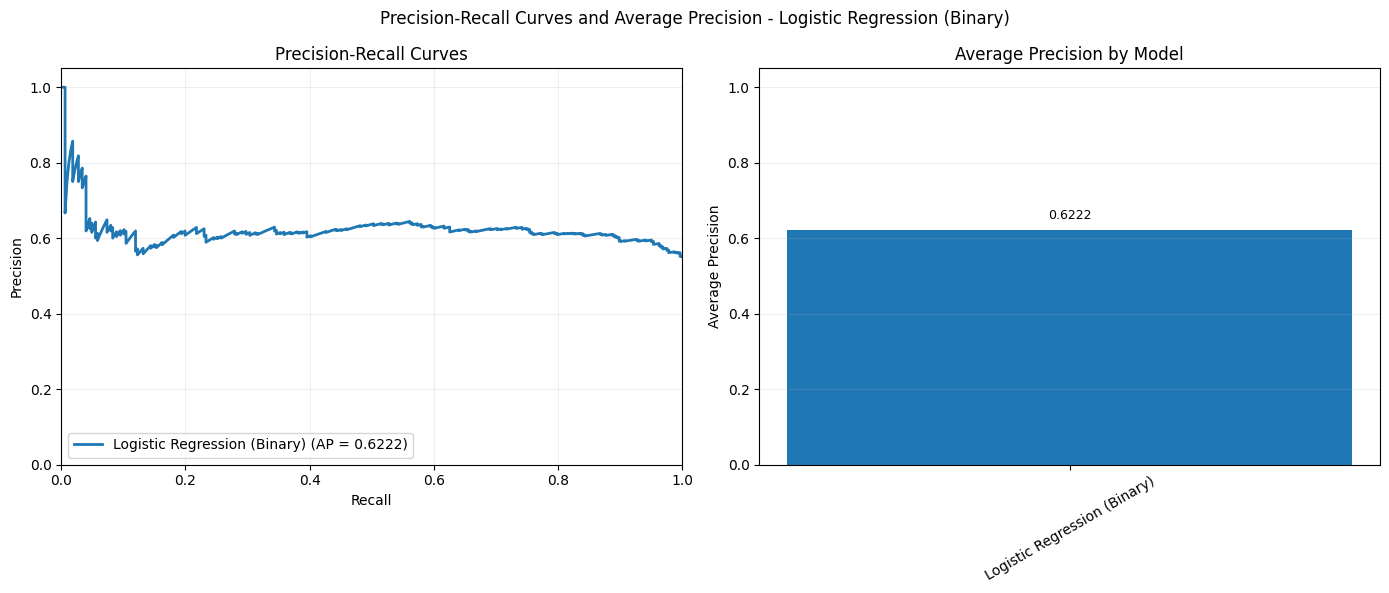

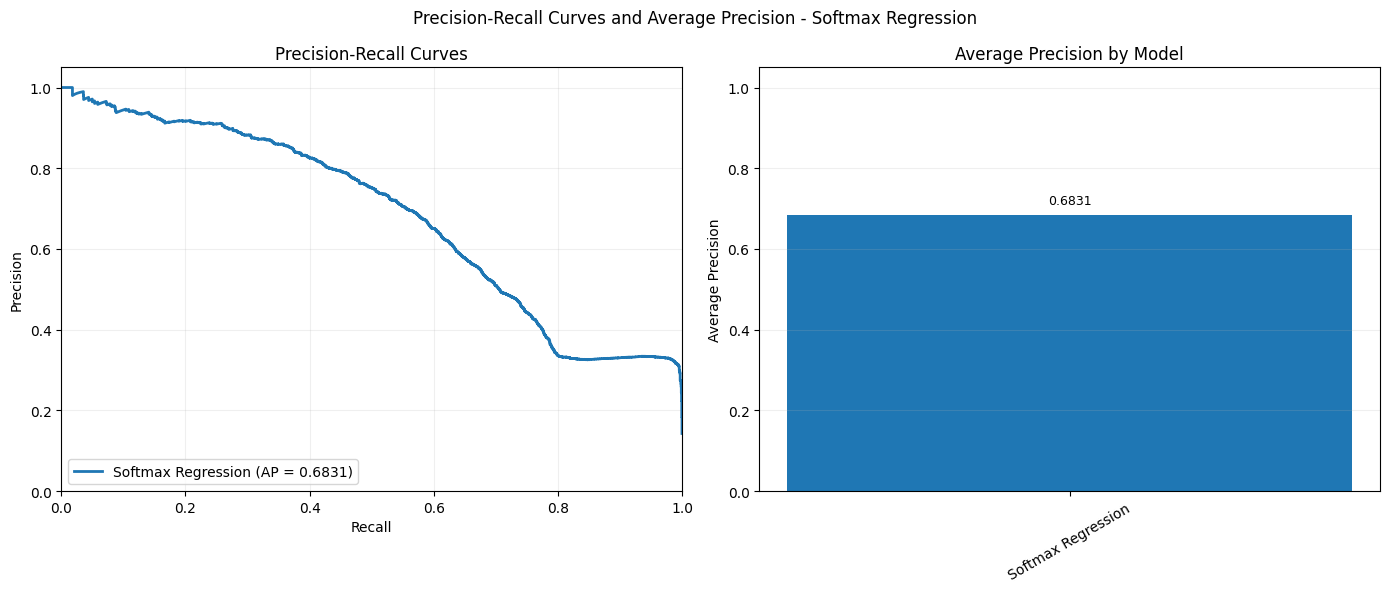

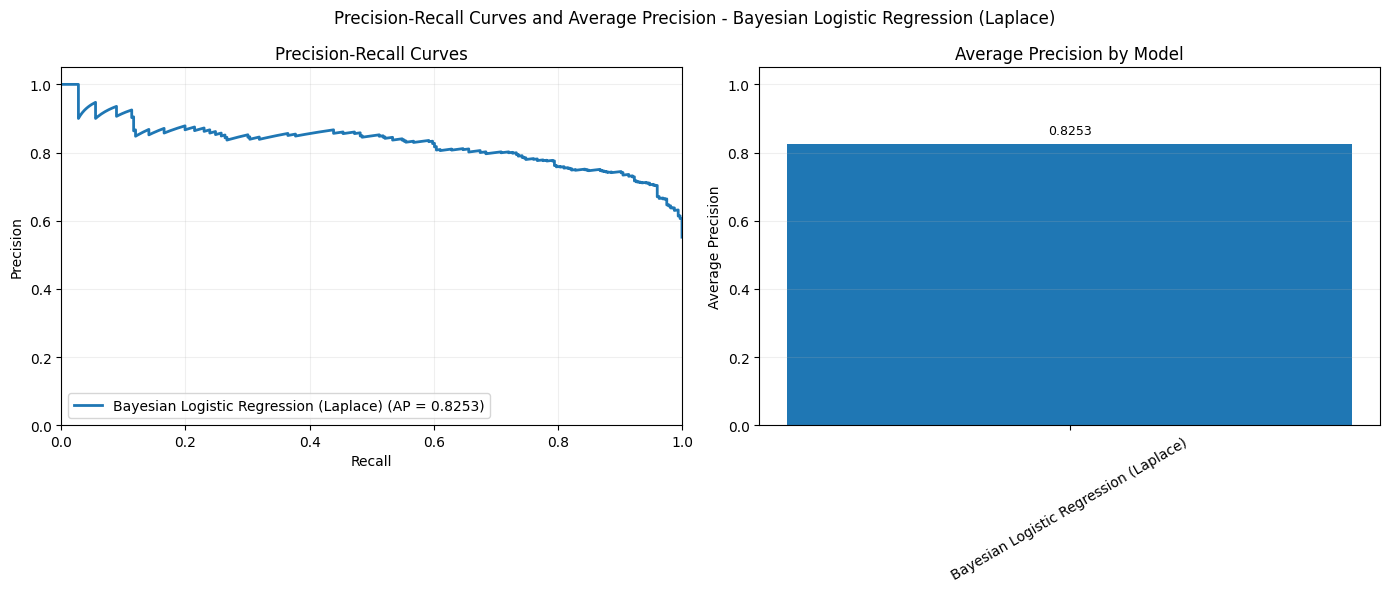

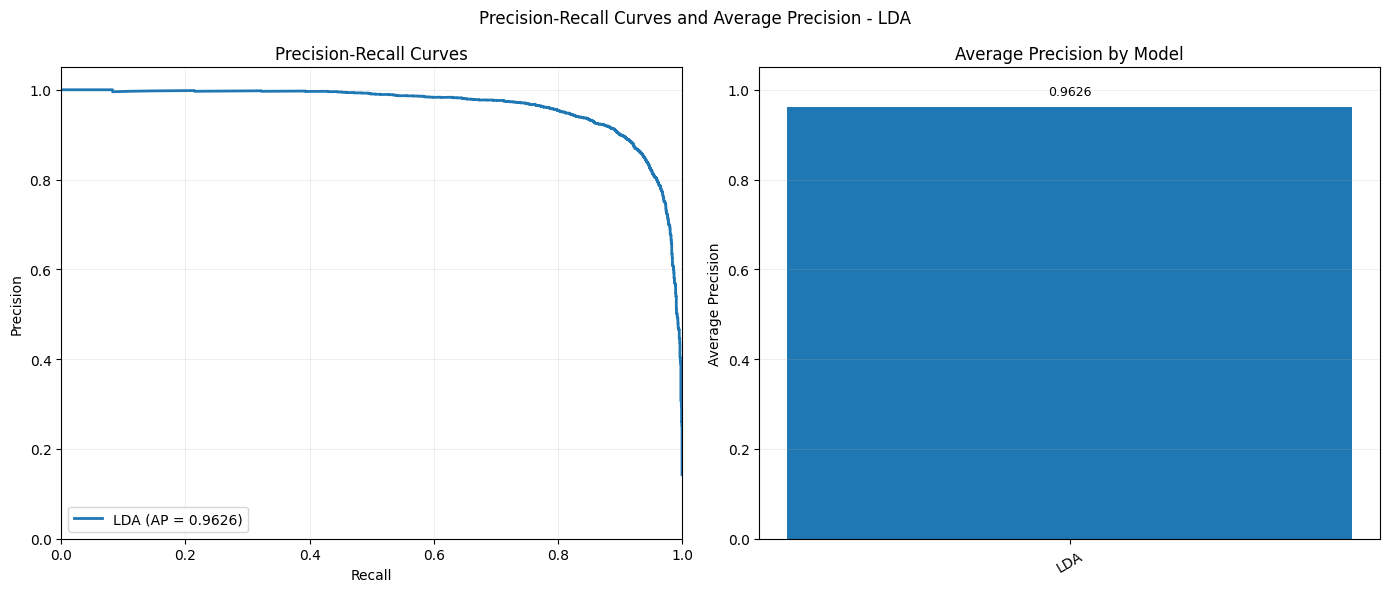

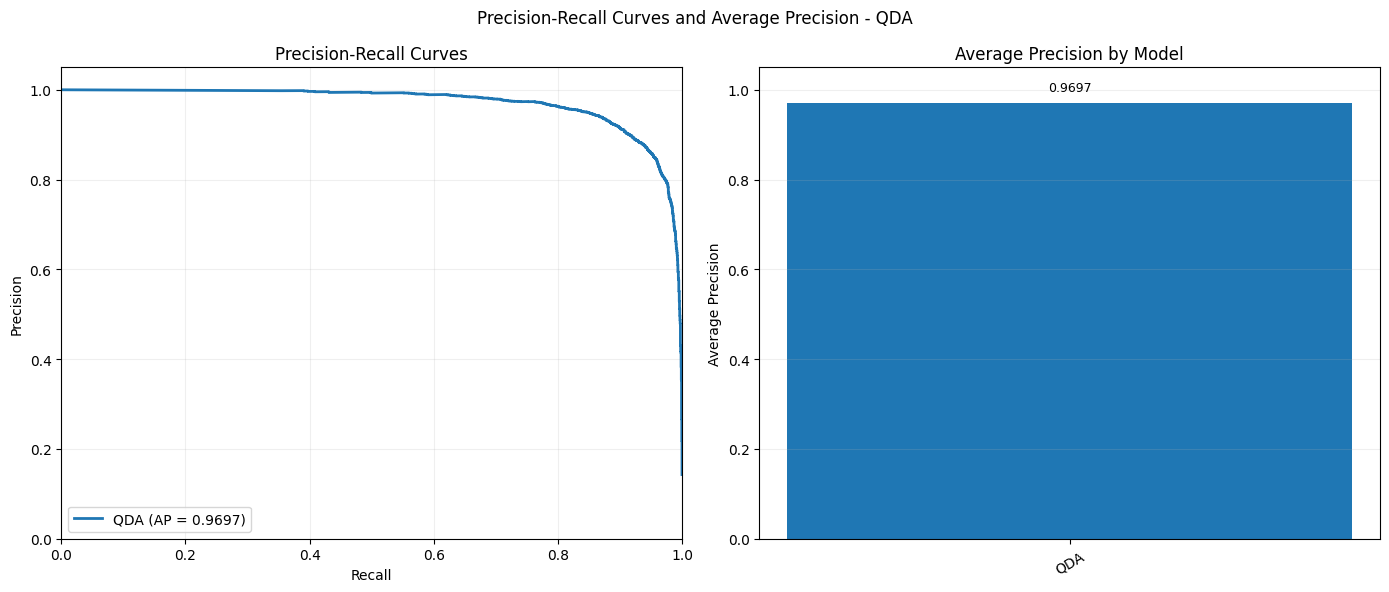

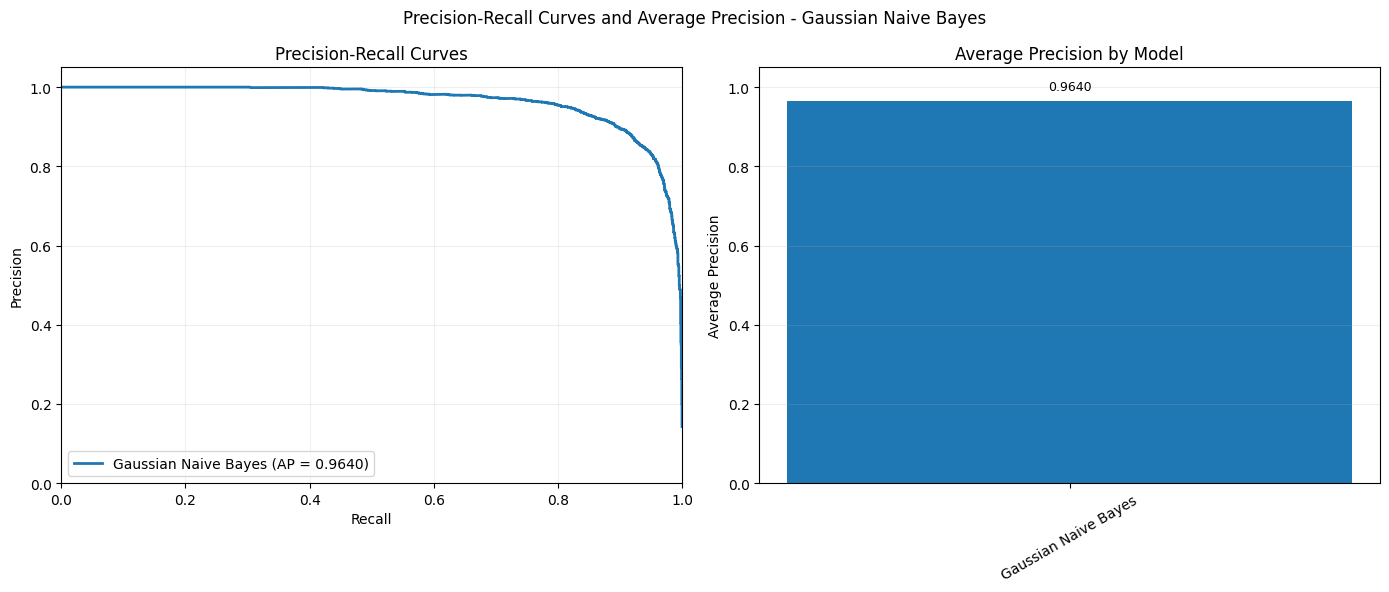

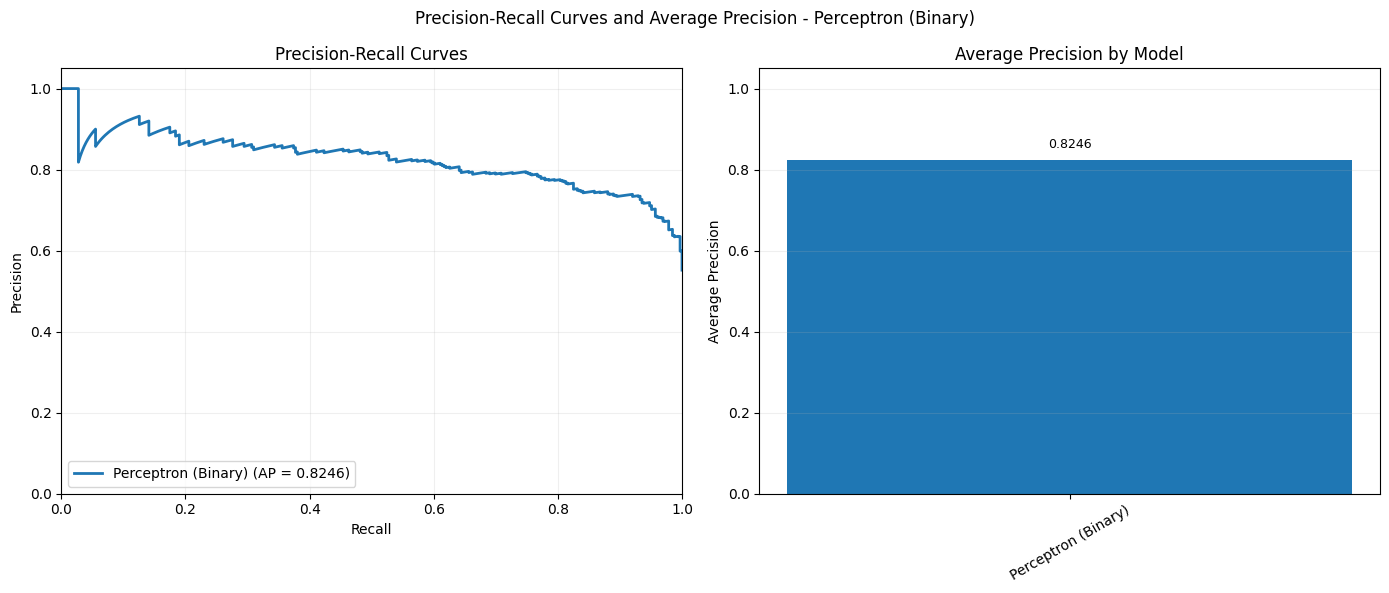

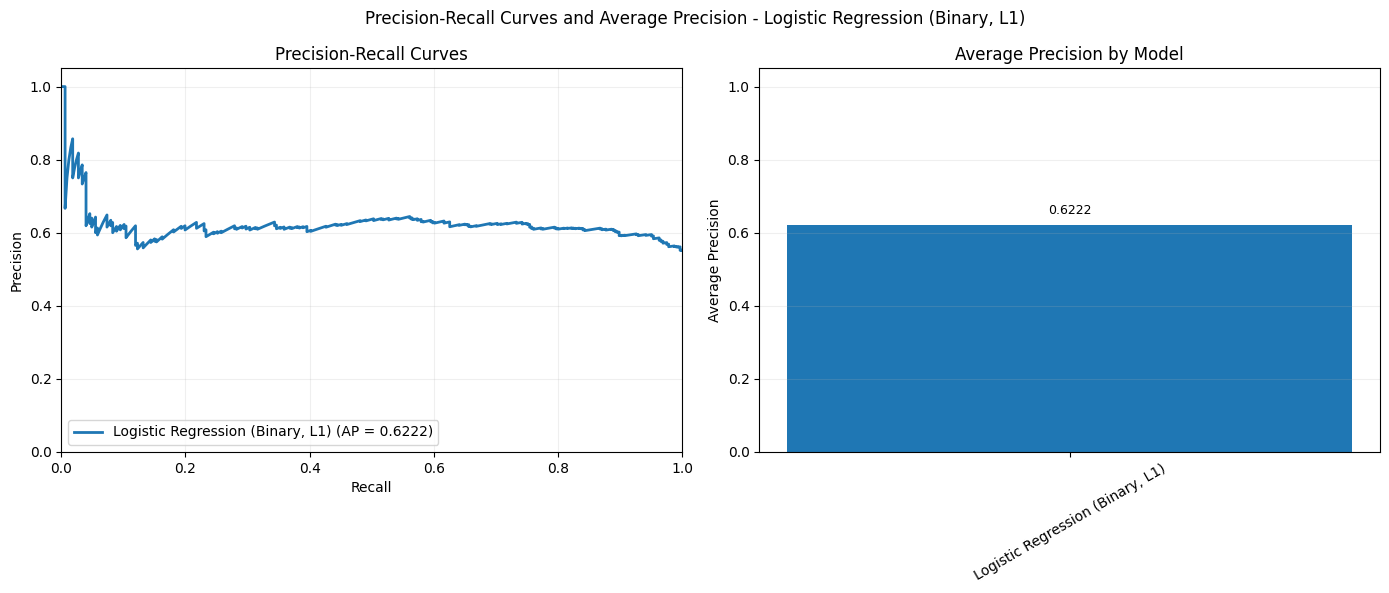

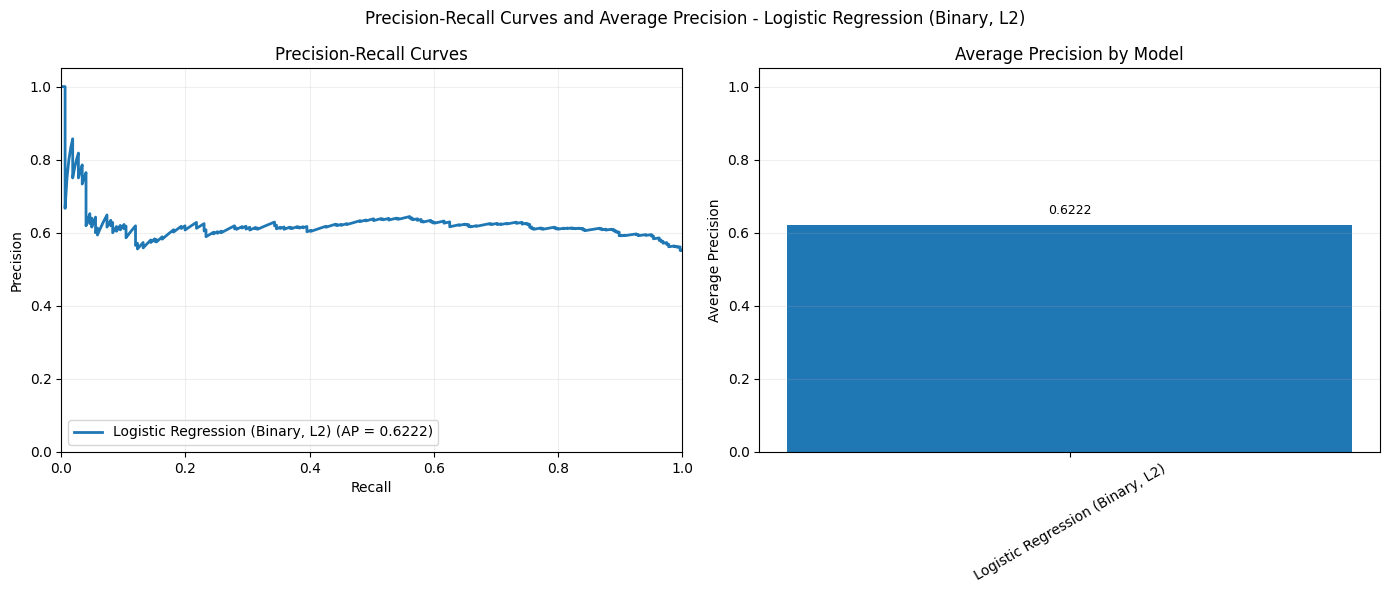

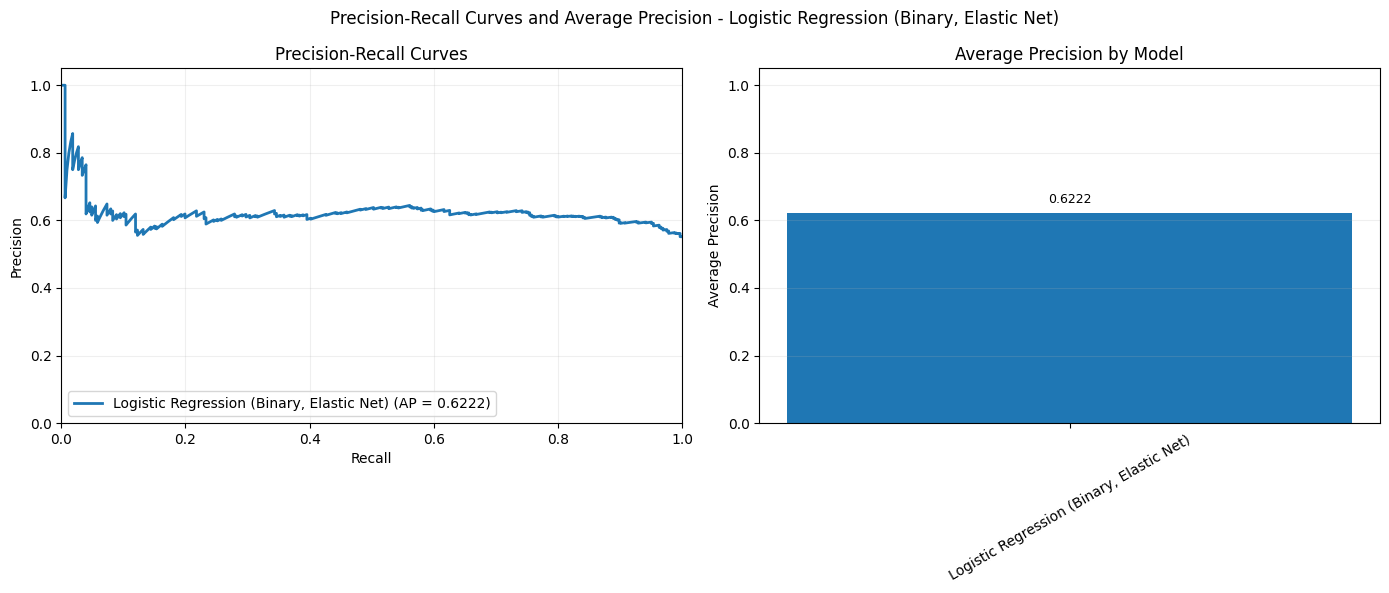

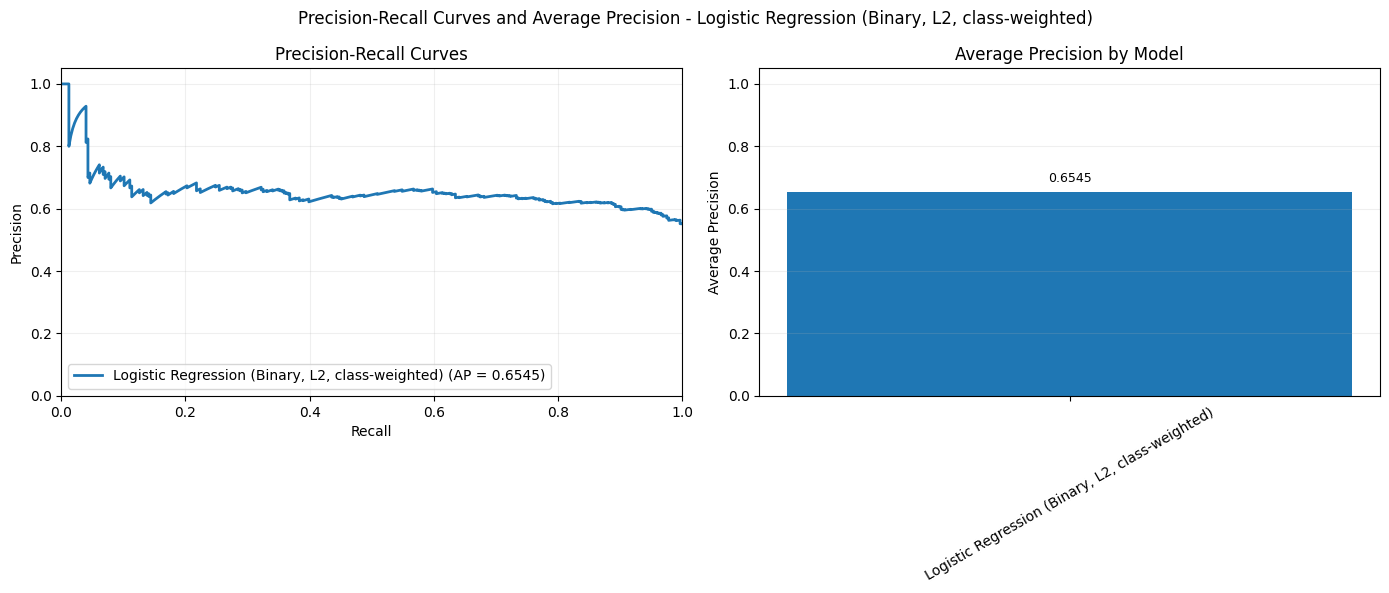

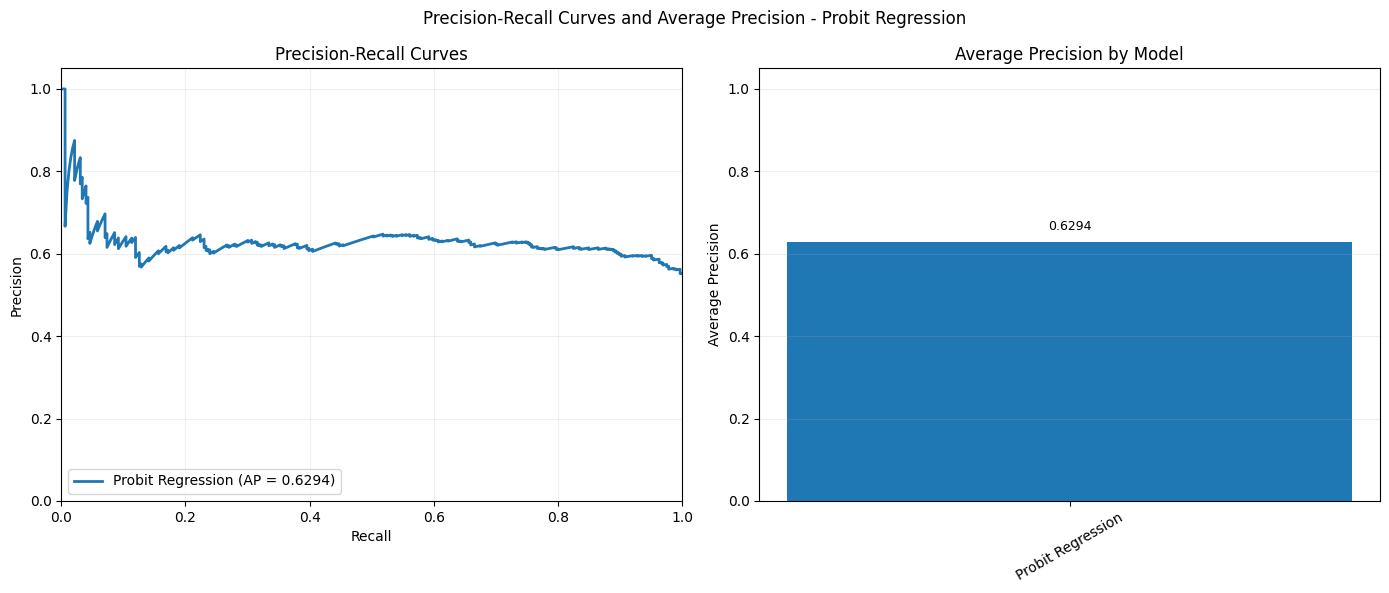

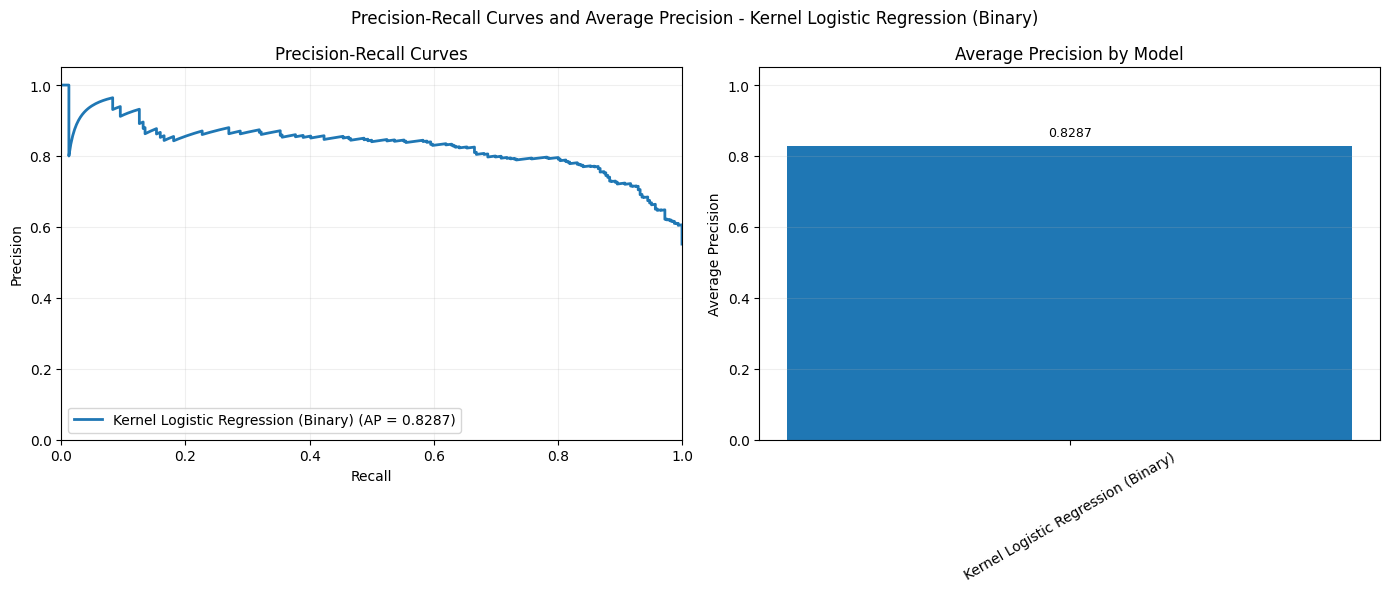


Average Precision by model:
QDA: 0.9697
Gaussian Naive Bayes: 0.9640
LDA: 0.9626
Kernel Logistic Regression (Binary): 0.8287
Bayesian Logistic Regression (Laplace): 0.8253
Perceptron (Binary): 0.8246
Softmax Regression: 0.6831
Logistic Regression (Binary, L2, class-weighted): 0.6545
Probit Regression: 0.6294
Logistic Regression (Binary): 0.6222
Logistic Regression (Binary, L1): 0.6222
Logistic Regression (Binary, L2): 0.6222
Logistic Regression (Binary, Elastic Net): 0.6222


In [ ]:
models_for_pr = {}
for name, model in models.items():
  if not hasattr(model, 'predict_proba'):
    print(f'Skip {name}: no predict_proba')
    continue

  is_binary_model = getattr(model, 'classes_', np.array([])).shape[0] == 2
  eval_X = X_test_bin if is_binary_model else X_test_scaled
  eval_y = y_test_bin if is_binary_model else y_test

  try:
    _ = model.predict_proba(eval_X[:5])
    models_for_pr[name] = (model, eval_X, eval_y)
  except Exception as e:
    print(f'Skip {name}: {e}')

if len(models_for_pr) == 0:
  raise ValueError('No valid models found for precision-recall plotting.')

ap_scores = {}
for name, (model, eval_X, eval_y) in models_for_pr.items():
  score = compare_average_precision(
    models={name: model},
    X=eval_X,
    y_true=eval_y,
    title=f'Precision-Recall Curves and Average Precision - {name}',
  )
  ap_scores.update(score)

print('\nAverage Precision by model:')
for name, score in sorted(ap_scores.items(), key=lambda x: x[1], reverse=True):
  print(f'{name}: {score:.4f}')

## 4.6 McNemar's test

**Cơ sở lý thuyết (ngắn gọn):** McNemar là kiểm định cho dữ liệu cặp (paired) trên cùng tập test, dùng để kiểm tra hai mô hình có khác biệt về tỉ lệ đúng/sai hay không.
- Giả thuyết không \(H_0\): hai mô hình có cùng xác suất sai khác trên cùng mẫu.
- Thông tin chính nằm ở hai ô bất đồng: `n01` (A sai, B đúng) và `n10` (A đúng, B sai).
- Nếu `n01 + n10` nhỏ, dùng kiểm định exact binomial; nếu đủ lớn, dùng xấp xỉ chi-square có continuity correction.
- Kết luận dựa trên `p-value` so với `alpha`.

In [ ]:
perceptron_bin_preds = perceptron_clf.predict(X_test_bin)

pairs = [
  ('GNB', 'LDA', y_test, gnb_preds, lda_preds),
  ('GNB', 'QDA', y_test, gnb_preds, qda_preds),
  ('LDA', 'QDA', y_test, lda_preds, qda_preds),
  ('Softmax', 'LDA', y_test, softmax_preds, lda_preds),
  ('Softmax', 'QDA', y_test, softmax_preds, qda_preds),
  ('Perceptron (Binary)', 'LR', y_test_bin, perceptron_bin_preds, logreg_preds),
  ('Perceptron (Binary)', 'BLR', y_test_bin, perceptron_bin_preds, blr_preds),
  ('LR', 'BLR', y_test_bin, logreg_preds, blr_preds),
  ('LR-L2', 'LR-L2-balanced', y_test_bin, logreg_l2_preds, logreg_l2_balanced_preds),
]

for name1, name2, y_true_pair, preds1, preds2 in pairs:
  result = mcnemar_paired(
    y_true=y_true_pair,
    y_pred_a=preds1,
    y_pred_b=preds2,
  )

  a_correct = preds1 == y_true_pair
  b_correct = preds2 == y_true_pair
  n00 = int((~a_correct & ~b_correct).sum())
  n01 = int((~a_correct & b_correct).sum())
  n10 = int((a_correct & ~b_correct).sum())
  n11 = int((a_correct & b_correct).sum())

  p_value = float(result['pvalue'])
  method = result['method']

  print(f"\nMcNemar test between {name1} and {name2}")
  print(f"Contingency table (A={name1}, B={name2}):")
  print(f"  n00 (A wrong, B wrong): {n00}")
  print(f"  n01 (A wrong, B correct): {n01}")
  print(f"  n10 (A correct, B wrong): {n10}")
  print(f"  n11 (A correct, B correct): {n11}")
  print(f"Method: {method}")
  print(f"p-value: {p_value:.6f}")

  if p_value < ALPHA:
    print(f"Kết luận: Bác bỏ H0 ở alpha={ALPHA}. Hai mô hình khác biệt có ý nghĩa thống kê.")
  else:
    print(f"Kết luận: Chưa bác bỏ H0 ở alpha={ALPHA}. Chưa đủ bằng chứng khác biệt có ý nghĩa thống kê.")

NameError: name 'logreg_l2_preds' is not defined

## 4.7 Phân tích Calibration của xác suất đầu ra bằng reliability diagram.

**Cơ sở lý thuyết (ngắn gọn):**
- Calibration đo mức độ “xác suất dự đoán” có khớp với tần suất thực tế hay không.
- Reliability diagram so sánh xác suất dự đoán trung bình với tỉ lệ dương tính thực nghiệm theo từng bin.
- Đường càng gần đường chéo càng tốt; ECE nhỏ hơn thường cho thấy mô hình hiệu chỉnh xác suất tốt hơn.

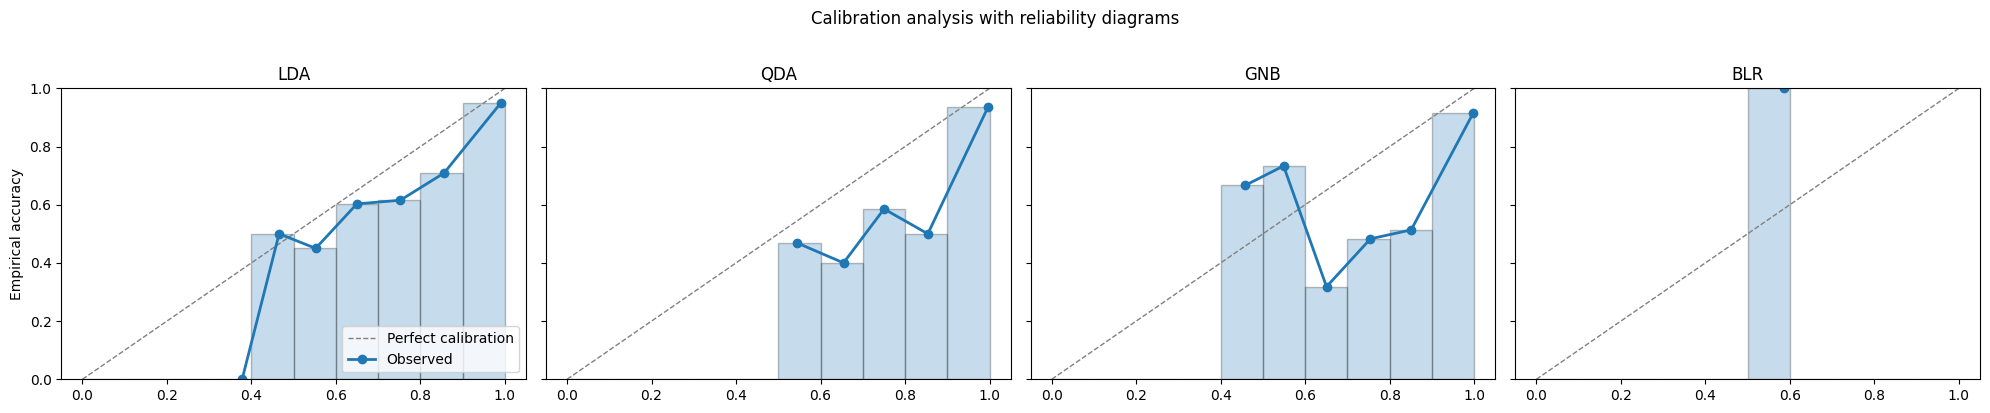

Calibration summary (lower ECE is better):
LDA: ECE=0.0517, avg_confidence=0.6635, avg_accuracy=0.5469
QDA: ECE=0.0726, avg_confidence=0.7598, avg_accuracy=0.5780
GNB: ECE=0.0907, avg_confidence=0.7101, avg_accuracy=0.6049
BLR: ECE=0.4139, avg_confidence=0.5861, avg_accuracy=1.0000


In [ ]:
# Models already fitted earlier in the notebook
models_for_calibration = {
  'LDA': (lda, X_test_scaled, y_test),
  'QDA': (qda, X_test_scaled, y_test),
  'GNB': (gnb, X_test_scaled, y_test),
  'BLR': (blr, X_test_bin, y_test_bin),
}

fig, axes = plt.subplots(
  1,
  len(models_for_calibration),
  figsize=(5 * len(models_for_calibration), 4),
  sharey=True,
)

if len(models_for_calibration) == 1:
  axes = [axes]

calibration_summary = []

for ax, (model_name, payload) in zip(axes, models_for_calibration.items()):
  model, eval_X, eval_y = payload
  y_prob = model.predict_proba(eval_X)
  if y_prob.ndim == 1:
    y_prob = np.column_stack([1 - y_prob, y_prob])

  bin_centers, counts, conf_mean, acc_mean, ece = reliability_diagram_multiclass(
    y_true=eval_y,
    probs=y_prob,
    class_labels=model.classes_,
    n_bins=N_BINS,
)

  valid = ~np.isnan(conf_mean) & ~np.isnan(acc_mean)

  ax.plot([0, 1], [0, 1], '--', color='gray', linewidth=1, label='Perfect calibration')
  ax.plot(conf_mean[valid], acc_mean[valid], marker='o', linewidth=2, label='Observed')
  ax.bar(
    bin_centers,
    np.nan_to_num(acc_mean, nan=0.0),
    width=1.0 / N_BINS,
    alpha=0.25,
    edgecolor='black',
  )
  ax.set_ylim(0, 1)
  ax.set_title(model_name)

  calibration_summary.append({
    'model': model_name,
    'ece': ece,
    'avg_confidence': float(np.nanmean(conf_mean)),
    'avg_accuracy': float(np.nanmean(acc_mean)),
  })

axes[0].set_ylabel('Empirical accuracy')
axes[0].legend(loc='lower right')
plt.suptitle('Calibration analysis with reliability diagrams', y=1.02)
plt.tight_layout()
plt.show()

calibration_summary = sorted(calibration_summary, key=lambda x: x['ece'])
print('Calibration summary (lower ECE is better):')
for row in calibration_summary:
  print(
    f"{row['model']}: "
    f"ECE={row['ece']:.4f}, "
    f"avg_confidence={row['avg_confidence']:.4f}, "
    f"avg_accuracy={row['avg_accuracy']:.4f}"
  )

## 4.8 Vẽ ROC Curve và AUC

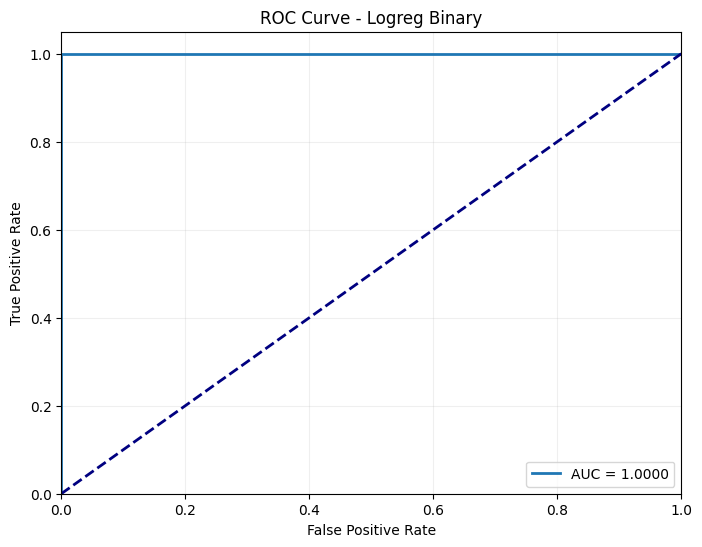

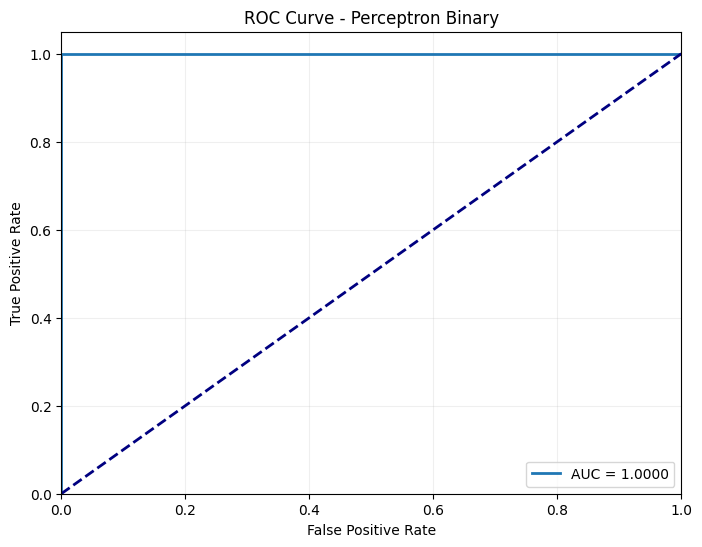

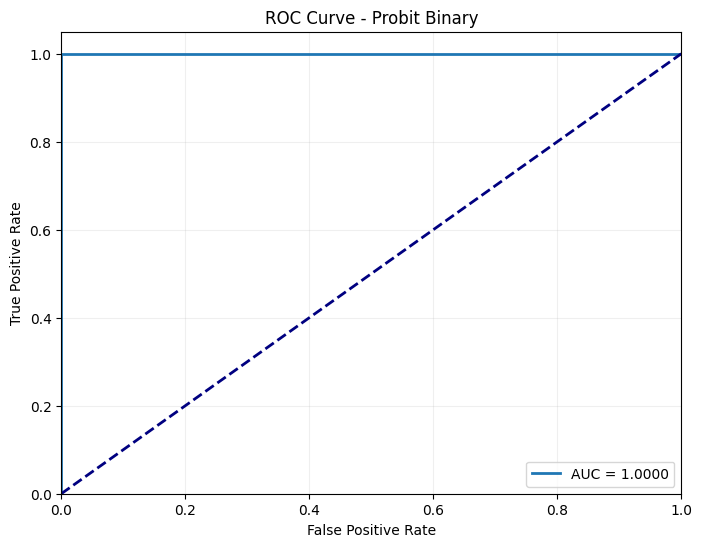

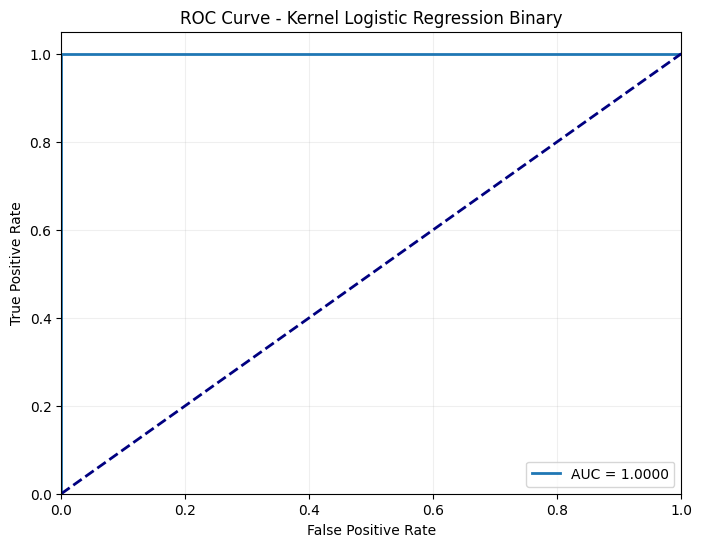

In [ ]:
roc_candidates = {
  'logreg': logreg,
  'perceptron': perceptron_clf,
  'probit': probit_model,
  'kernel logistic regression': kernel_model,
}
roc_models = collect_models_with_attr(roc_candidates, 'predict_proba')

for name, model in roc_models.items():
  try:
    plot_roc_curve(model, X_test_bin, y_test_bin, title=f'ROC Curve - {name.title()} Binary')
  except Exception as e:
    print(f'Could not plot ROC for {name}:', e)


## 5. Nhan xet bieu do va doi chieu ly thuyet

### 5.1 EDA

- Bieu do phan bo lop cho thay muc do mat can bang cua du lieu. Neu mot so lop co tan suat thap hon ro ret, Accuracy co the bi lac quan, vi vay can uu tien them Precision/Recall/F1 theo lop va AP.
- Heatmap tuong quan phan anh muc do dong bien giua cac dac trung. Tuong quan cao giua nhieu cap bien co the lam mo bien quyet dinh tuyen tinh, va regularization (dac biet L2) giup on dinh nghiem.
- Bieu do phan bo dac trung theo lop cho thay cac dac trung co kha nang tach lop manh (cac phan bo it chong lap), phu hop voi Fisher ratio cao.

### 5.2 Fisher ratio va LDA/QDA

- Bieu do Fisher ratio la bang chung truc tiep cho muc do discriminability cua tung dac trung. Dac trung co $J_j$ cao dong gop manh vao viec tach lop.
- Khong gian chieu LDA 2D giu lai huong phan biet manh nhat, nen neu cac cum lop da tach ro trong khong gian nay thi LDA thuong dat hieu qua tot.
- Neu ranh gioi quan sat co xu huong cong va phan tan theo lop khac nhau, QDA co co so ly thuyet de vuot LDA vi cho phep hiep phuong sai rieng tung lop.

### 5.3 Toi uu hoa va hoi tu

- Duong loss cho Logistic GD va Newton-IRLS thuong cho thay Newton giam loss nhanh hon theo so vong lap nho thong tin Hessian (thong tin bac hai).
- O goc nhin wall-clock, Newton moi vong dat hon do can xu ly Hessian, nhung van thuong dat diem hoi tu tot voi it vong lap hon.
- Perceptron hoi tu nhanh tren du lieu linearly separable (dung voi dinh ly hoi tu perceptron), trong khi tren du lieu XOR-like (khong tach tuyen tinh) loss khong the ve 0.

### 5.4 Danh gia mo hinh

- Precision-Recall va AP huu ich hon ROC khi du lieu mat can bang, vi PR tap trung truc tiep vao chat luong lop duong.
- Reliability diagram: duong observed nam gan duong cheo la calibration tot; ECE cang nho cang tot.
- McNemar test giup tra loi cau hoi ve y nghia thong ke cua chenh lech hieu nang tren cung tap test, tranh ket luan dua tren chenh lech nho khong on dinh.
- Confusion matrix cho thay cap lop nao de nham lan nhat; ket hop voi thong ke feature shift tren cac mau sai giup giai thich sai sot duoi goc nhin du lieu va mo hinh.

### 5.5 Logistic Regression vs LDA (discriminative vs generative)

- Logistic Regression la mo hinh discriminative: toi uu truc tiep $p(y\mid x)$, it phu thuoc vao gia thiet Gaussian cho dac trung, nen thuong ben vung hon khi mo hinh hoa phan phoi dau vao bi sai.
- LDA la mo hinh generative: mo hinh hoa $p(x\mid y)$ va $p(y)$, sau do suy ra $p(y\mid x)$ bang Bayes. Khi gia thiet Gaussian va hiep phuong sai chung gan dung, LDA co the hoc on dinh hon o kich thuoc mau vua/nhỏ.
- Neu du lieu mat can bang, can uu tien F1 theo lop, PR curve va AP ben canh Accuracy; class-weighted loss giup dich chuyen bien quyet dinh de tranh thien vi ve lop da so.
- Khi ranh gioi that su phi tuyen, mo hinh tuyen tinh (LR/Perceptron/LDA) se co tran hieu nang; Kernel Logistic Regression co the cai thien nho anh xa kernel nhung doi lai chi phi huan luyen va giai thich tang len.

## 6. Discussion tổng kết

Kết quả sau khi đồng bộ toàn bộ pipeline cho thấy bài toán phân lớp hiện tại có cấu trúc **không hoàn toàn tuyến tính**, nhưng mức phi tuyến chưa quá cực đoan. Trong nhóm mô hình cốt lõi, Logistic (kèm regularization), LDA/QDA và Softmax đều tạo baseline mạnh; thứ hạng giữa chúng ổn định hơn khi nhìn đồng thời trên test split, `k-fold CV` và các biểu đồ PR/ROC thay vì chỉ một chỉ số đơn lẻ.

Phần tối ưu hóa cho Logistic cho kết quả đúng với lý thuyết: Newton/IRLS giảm loss nhanh hơn theo số vòng lặp so với GD, nhưng chi phí mỗi bước cao hơn do xử lý Hessian. Vì vậy, nếu ưu tiên tốc độ hội tụ theo iteration thì Newton có lợi; nếu ưu tiên chi phí tính toán đơn giản và dễ mở rộng thì GD vẫn là lựa chọn thực dụng.

`LDA` và `QDA` là cặp cần diễn giải theo giả thiết phân phối: khi hiệp phương sai các lớp gần nhau hoặc dữ liệu mỗi lớp chưa đủ lớn, LDA thường ổn định hơn; khi biên quyết định thực sự cong và mỗi lớp có cấu trúc phân tán khác nhau rõ rệt, QDA có thể vượt lên. Fisher ratio và không gian chiếu LDA 2D là bằng chứng trực quan tốt để giải thích tại sao một số lớp dễ tách hơn các lớp còn lại.

Ở nhánh regularized Logistic, `L1`, `L2` và `Elastic Net` cho thấy tác dụng chính là kiểm soát độ phức tạp và cải thiện độ ổn định thay vì luôn tạo bước nhảy lớn về accuracy. `Class-weighted loss` đặc biệt hữu ích khi dữ liệu có mất cân bằng, vì nó dịch chuyển biên quyết định theo hướng tăng độ nhạy cho lớp thiểu số và thường phản ánh rõ hơn qua Recall/F1 và PR curve.

Các bonus models nên được đọc đúng phạm vi. `Probit` chủ yếu là đối chứng phân phối link function so với Logistic; `Laplace approximation` bổ sung góc nhìn uncertainty-aware cho mô hình phân biệt; `Kernel Logistic Regression` giúp xử lý biên phi tuyến tốt hơn nhưng đánh đổi chi phí huấn luyện và khả năng diễn giải. Vì vậy, bonus nên được trình bày như phần mở rộng có kiểm soát, không thay thế hoàn toàn kết luận chính từ nhóm mô hình nền tảng.

Tóm lại, một kết luận hợp lý cho phần classification là:
- **baseline tuyến tính** (Logistic/LDA/Softmax) vẫn là nền bắt buộc vì ổn định và dễ giải thích,
- **regularization + class-weighted loss** là cấu phần quan trọng để tăng robustness trong bối cảnh mất cân bằng,
- **QDA và Kernel Logistic** là hai hướng cải thiện khi dữ liệu thể hiện phi tuyến rõ,
- **PR/AP, calibration và McNemar** cần đi cùng Accuracy để tránh kết luận một chiều,
- **bonus models** nên được báo cáo kèm phạm vi áp dụng và chi phí tính toán để đảm bảo diễn giải công bằng.
